# Segmentation and Association — Structural Clustering
## Madrid Rental Market — Machine Learning I

---

**Approach:** Cluster on **5 structural variables** (Sq.Mt, Bedrooms, Floor, Is_Special, Outer), then profile clusters across **all remaining variables** (Rent, Price/m², Elevator, District, property types, spaciousness).

- We use **k=5** based on silhouette analysis and business interpretability. While the elbow method may suggest k=3–4, k=5 captures the **height premium** (high-floor vs low-floor exterior flats) — a real pricing mechanism in dense cities like Madrid driven by light, noise, and views.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('All libraries loaded successfully')

All libraries loaded successfully


In [2]:
# Load cleaned dataset (from EDA phase)
# NOTE: Change filename to match your cleaned file
df = pd.read_excel('HousesMadridClean.xlsx')

print(f'Cleaned dataset: {df.shape[0]} properties, {df.shape[1]} variables')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Cleaned dataset: 2085 properties, 14 variables
Missing values: 0


,Id,District,Address,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,Quintana,1300,2,72,3.0,1,1,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,Costillares,3000,5,260,2.0,1,1,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,Colina,1300,2,100,3.0,1,1,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,San Pascual,1600,3,120,4.0,1,1,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,Ventas,800,2,60,3.0,1,0,0,0,0,0


## 2. Variable Description & Roles

Before clustering, we must clearly define what each variable represents and how we will use it.

### Available Variables

| Variable | Description | Type | Role |
|----------|------------|------|------|
| **Sq.Mt** | Total area of the property in square meters | Continuous | **Clustering** — core physical dimension |
| **Bedrooms** | Number of bedrooms (0 = studio) | Discrete | **Clustering** — defines property capacity |
| **Floor** | Floor number (-1 = basement, 0 = ground) | Discrete | **Clustering** — vertical position in building |
| **Is_Special** | 1 if Penthouse, Cottage, Duplex or Semidetached | Binary | **Clustering** — flags non-standard property types |
| **Outer** | 1 if the property faces the exterior (street-facing, natural light) | Binary | **Clustering** — structural constraint (cannot be renovated) |
| **Rent** | Monthly rental price in euros | Continuous | **Profiling** — market outcome, not a property characteristic |
| **Price_per_sqm** | Rent ÷ Sq.Mt — cost efficiency | Derived | **Profiling** — derived from Rent |
| **Elevator** | 1 if the building has an elevator | Binary | **Profiling** — amenity/comfort indicator |
| **District** | Madrid district name (20 districts) | Categorical | **Profiling** — location, discovered after clustering |
| **Penthouse** | 1 if penthouse | Binary | **Profiling** — specific type within Is_Special |
| **Cottage** | 1 if cottage/chalet | Binary | **Profiling** — specific type within Is_Special |
| **Duplex** | 1 if duplex | Binary | **Profiling** — specific type within Is_Special |
| **Semidetached** | 1 if semidetached house | Binary | **Profiling** — specific type within Is_Special |
| **SqMt_per_Bed** | Sq.Mt ÷ Bedrooms — spaciousness per room | Derived | **Profiling** — comfort/density indicator |

### Why this split?

**Clustering variables** describe **what the property physically IS** — its permanent structure. These don't change with the market.

**Profiling variables** describe **outcomes and qualities** — price is set by the market, amenities describe desirability, location describes geography. We discover these patterns AFTER clustering to avoid circular logic.

**Key decisions:**
- **Outer → Clustering:** Unlike an elevator (which can be installed), exterior/interior orientation is a permanent structural constraint. An interior flat cannot become exterior through renovation. This makes `Outer` a defining physical characteristic, not a market-dependent amenity.
- **Elevator → Profiling:** Elevators can be retrofitted. It is more interesting to *discover* whether certain structural types tend to have elevators than to force the algorithm to separate them.
- **Rent → Profiling:** Rent is a market outcome. Clustering on it creates circular logic (clusters defined by price are trivially "different" in price).

## 3. Feature Engineering

In [3]:
# ── Feature Engineering ──

# CLUSTERING FEATURE
# Is_Special: Combines all non-standard property types into one flag
# Why: Penthouse/Cottage/Duplex/Semidetached individually are too rare (3-8%)
# to form their own clusters, but together (15%) they represent a meaningful segment
df['Is_Special'] = ((df['Penthouse'] == 1) | (df['Cottage'] == 1) | 
                    (df['Duplex'] == 1) | (df['Semidetached'] == 1)).astype(int)

# PROFILING FEATURES (used AFTER clustering, never during)

# Price per m²: normalizes rent by size
df['Price_per_sqm'] = (df['Rent'] / df['Sq.Mt']).round(2)

# m² per Bedroom: measures spaciousness
df['SqMt_per_Bed'] = (df['Sq.Mt'] / df['Bedrooms'].replace(0, np.nan)).round(1)

# District Premium: numerical proxy for location quality
district_median = df.groupby('District')['Rent'].median()
df['District_Premium'] = df['District'].map(district_median)

# Geographic zone (for profiling and association analysis)
zone_map = {
    'Salamanca': 'Prime Center', 'Chamberí': 'Prime Center', 'Retiro': 'Prime Center',
    'Centro': 'Historic Core',
    'Chamartín': 'Business North', 'Tetuán': 'Business North',
    'Moncloa': 'University/West', 'Arganzuela': 'University/West',
    'Hortaleza': 'Suburban Premium', 'Fuencarral': 'Suburban Premium', 'Barajas': 'Suburban Premium',
    'Ciudad Lineal': 'Suburban Standard', 'San Blás': 'Suburban Standard', 'Moratalaz': 'Suburban Standard',
    'Latina': 'Working Class South', 'Carabanchel': 'Working Class South', 'Usera': 'Working Class South',
    'Puente Vallecas': 'Working Class South', 'Villa de Vallecas': 'Working Class South', 'Vicálvaro': 'Working Class South'
}
df['Zone'] = df['District'].map(zone_map)

# Is_Central (for logit model target)
df['Is_Central'] = df['Zone'].isin(['Prime Center', 'Historic Core']).astype(int)

# Studio detection from Address field
df['Is_Studio'] = df['Address'].str.contains('Estudio', case=False, na=False).astype(int)

print('Features created:')
print(f'  Is_Special:       {df["Is_Special"].sum()} properties ({df["Is_Special"].mean()*100:.1f}%)')
print(f'  Price_per_sqm:    €{df["Price_per_sqm"].median():.1f} median')
print(f'  SqMt_per_Bed:     {df["SqMt_per_Bed"].median():.0f} m²/bedroom median')
print(f'  District_Premium: €{df["District_Premium"].min():.0f} – €{df["District_Premium"].max():.0f}')
print(f'  Is_Central:       {df["Is_Central"].sum()} ({df["Is_Central"].mean()*100:.0f}%)')
print(f'  Is_Studio:        {df["Is_Studio"].sum()} (extracted from Address)')

Features created:
  Is_Special:       321 properties (15.4%)
  Price_per_sqm:    €14.9 median
  SqMt_per_Bed:     47 m²/bedroom median
  District_Premium: €700 – €2500
  Is_Central:       868 (42%)
  Is_Studio:        92 (extracted from Address)


## 4. Variable Selection for Clustering

**Clustering on 5 structural variables:**
- `Sq.Mt` — property size
- `Bedrooms` — capacity/layout
- `Floor` — vertical position
- `Is_Special` — standard vs non-standard type
- `Outer` — exterior/interior orientation (structural constraint)

Everything else is reserved for profiling — this gives us **9 profiling variables** to examine per cluster.

In [4]:
# ── Variable Selection ──
clustering_vars = ['Sq.Mt', 'Bedrooms', 'Floor', 'Is_Special', 'Outer']
X = df[clustering_vars].copy()

print('CLUSTERING VARIABLES (5 structural features)')
print('=' * 60)
for var in clustering_vars:
    print(f'  {var:15s}  range: {X[var].min():.0f} – {X[var].max():.0f}  (mean: {X[var].mean():.1f})')
print(f'\nShape: {X.shape[0]} properties × {X.shape[1]} features')

print('\nPROFILING VARIABLES (examined AFTER clustering)')
print('=' * 60)
profiling_vars = ['Rent', 'Price_per_sqm', 'Elevator', 'District',
                  'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'SqMt_per_Bed']
for var in profiling_vars:
    print(f'  {var}')

CLUSTERING VARIABLES (5 structural features)
  Sq.Mt            range: 15 – 1250  (mean: 129.0)
  Bedrooms         range: 0 – 8  (mean: 2.5)
  Floor            range: -1 – 29  (mean: 3.5)
  Is_Special       range: 0 – 1  (mean: 0.2)
  Outer            range: 0 – 1  (mean: 0.9)

Shape: 2085 properties × 5 features

PROFILING VARIABLES (examined AFTER clustering)
  Rent
  Price_per_sqm
  Elevator
  District
  Penthouse
  Cottage
  Duplex
  Semidetached
  SqMt_per_Bed


## 5. Correlation Analysis

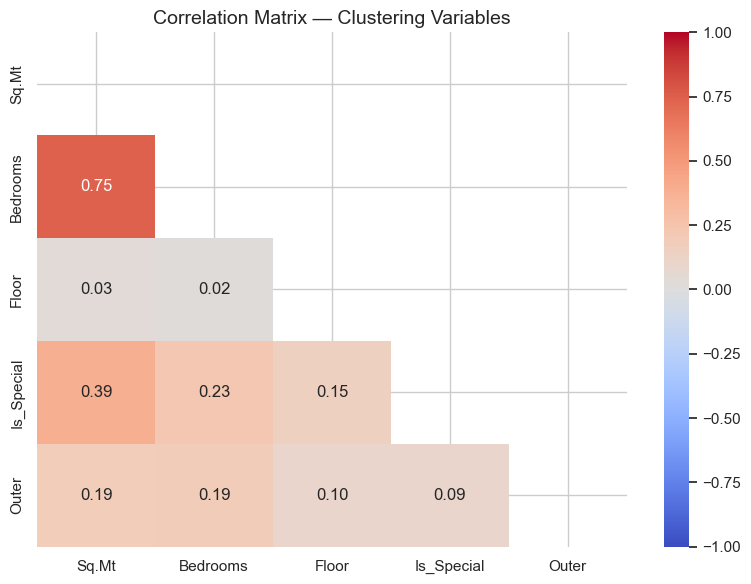

Notable correlations (|r| > 0.6):
  Sq.Mt ↔ Bedrooms: r = 0.750

Sq.Mt and Bedrooms are naturally correlated — larger flats have more rooms.
Both are kept because they capture distinct dimensions (total space vs layout).


In [5]:
# ── Correlation Matrix ──
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Clustering Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Check for problematic correlations
high_corr = [(corr.columns[i], corr.columns[j], corr.iloc[i,j])
             for i in range(len(corr.columns)) for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.6]

if high_corr:
    print('Notable correlations (|r| > 0.6):')
    for v1, v2, r in high_corr:
        print(f'  {v1} ↔ {v2}: r = {r:.3f}')
    print('\nSq.Mt and Bedrooms are naturally correlated — larger flats have more rooms.')
    print('Both are kept because they capture distinct dimensions (total space vs layout).')
else:
    print('No problematic correlations found (all |r| < 0.6).')

## 6. Standardization

K-Means uses Euclidean distance. Without standardization, Sq.Mt (range 15–1250) would dominate Bedrooms (range 0–8) simply because of scale, not importance. Binary variables (Is_Special, Outer) also benefit from being on the same scale.

In [6]:
# ── Standardize ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_vars, index=X.index)

print('After standardization (mean ≈ 0, std ≈ 1):')
print(X_scaled_df.describe().round(2).loc[['mean', 'std', 'min', 'max']])

After standardization (mean ≈ 0, std ≈ 1):
      Sq.Mt  Bedrooms  Floor  Is_Special  Outer
mean   0.00      0.00   0.00        0.00  -0.00
std    1.00      1.00   1.00        1.00   1.00
min   -0.98     -1.92  -1.56       -0.43  -2.67
max    9.68      4.32   8.80        2.34   0.37


## 7. Algorithm 1: Hierarchical Clustering (Exploratory)

**Purpose:** The dendrogram gives us a visual hint of natural groupings before committing to a k.

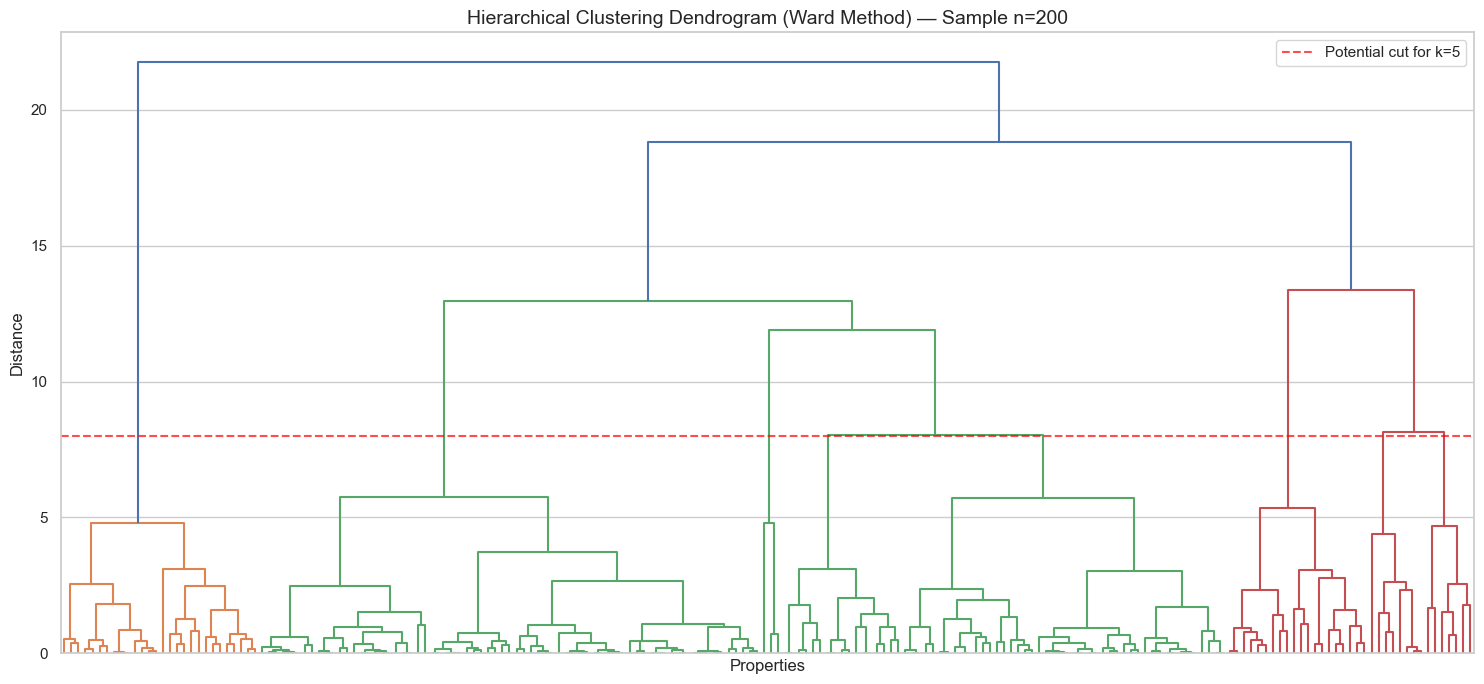

In [7]:
# ── Dendrogram (Ward linkage, sample of 200) ──
sample_size = 200
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, no_labels=True, color_threshold=0.7*max(linkage_matrix[:,2]))
plt.title('Hierarchical Clustering Dendrogram (Ward Method) — Sample n=200', fontsize=14)
plt.xlabel('Properties')
plt.ylabel('Distance')
plt.axhline(y=8, color='red', linestyle='--', alpha=0.7, label='Potential cut for k=5')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Hierarchical clustering on full data ──
hc_labels = {}
for k in [3, 4, 5]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hc_labels[k] = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, hc_labels[k])
    print(f'Hierarchical Ward k={k}: Silhouette={sil:.4f}, Sizes={np.bincount(hc_labels[k])}')

Hierarchical Ward k=3: Silhouette=0.4106, Sizes=[1428  401  256]
Hierarchical Ward k=4: Silhouette=0.4458, Sizes=[ 401  251  256 1177]
Hierarchical Ward k=5: Silhouette=0.4343, Sizes=[ 251  142  256 1177  259]


## 8. Algorithm 2: K-Means (Main)

**Why K-Means here:** Works well with our 5 continuous/binary features, fast, interpretable centroids.

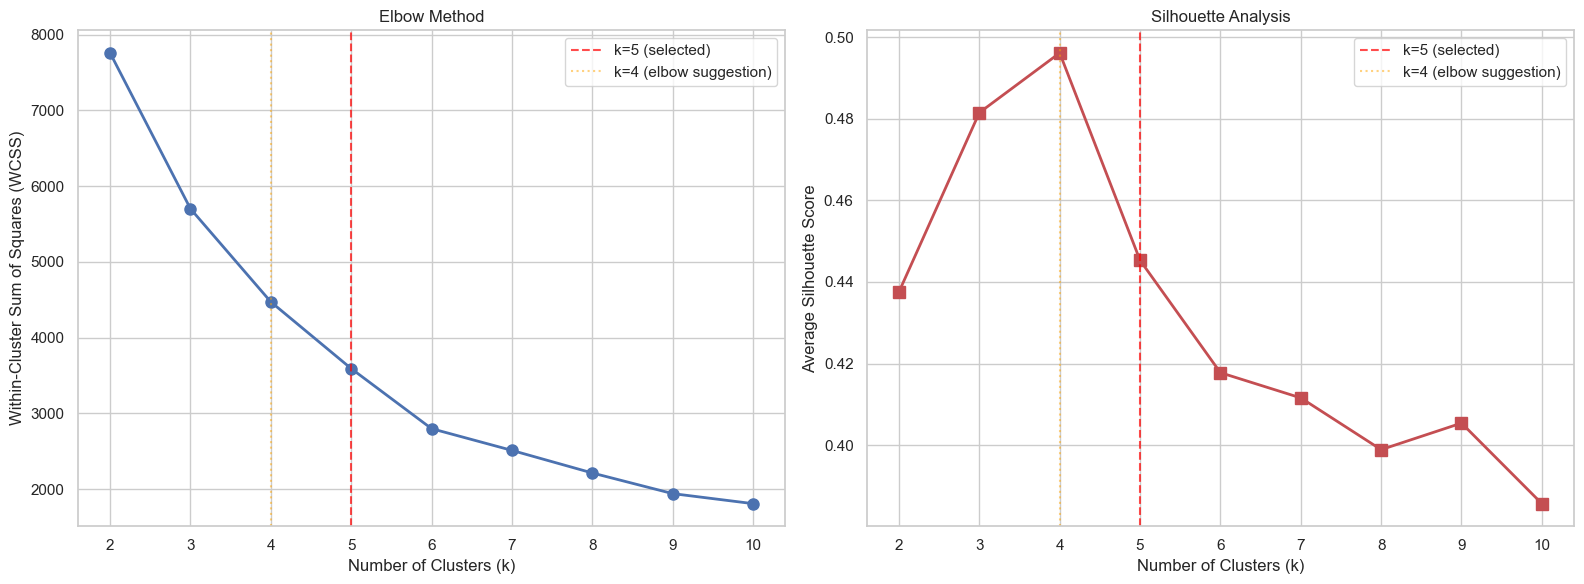


Silhouette scores:
  k=2: Silhouette=0.4376
  k=3: Silhouette=0.4815
  k=4: Silhouette=0.4961 (elbow)
  k=5: Silhouette=0.4453 ◄ SELECTED
  k=6: Silhouette=0.4178
  k=7: Silhouette=0.4116
  k=8: Silhouette=0.3989
  k=9: Silhouette=0.4054
  k=10: Silhouette=0.3857

SELECTION RATIONALE: k=5 over k=4
The silhouette score for k=4 is slightly higher than k=5.
However, silhouette is a mathematical metric that optimizes for
cluster compactness — it does not measure business usefulness.

k=5 is selected because:
  1. BALANCE: k=4 leaves ~67% in one catch-all "Standard" cluster
  2. HEIGHT PREMIUM: k=5 separates High-Floor (median floor 7,
     €1600 rent, €15.7/m²) from Low-Floor (median floor 2,
     €1300 rent, €14.4/m²) — a real pricing mechanism
  3. STABILITY: Interior, Luxury, and Penthouse clusters remain
     identical between k=4 and k=5
  4. ACTIONABILITY: A 67% cluster offers no pricing differentiation


In [9]:
# ── Elbow Method + Silhouette Analysis ──
K_range = range(2, 11)
wcss = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.set_title('Elbow Method')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (selected)')
ax1.axvline(x=4, color='orange', linestyle=':', alpha=0.5, label='k=4 (elbow suggestion)')
ax1.legend()

# Silhouette
ax2.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (selected)')
ax2.axvline(x=4, color='orange', linestyle=':', alpha=0.5, label='k=4 (elbow suggestion)')
ax2.legend()

plt.tight_layout()
plt.show()

print('\nSilhouette scores:')
for k, s in zip(K_range, sil_scores):
    marker = ' ◄ SELECTED' if k == 5 else (' (elbow)' if k == 4 else '')
    print(f'  k={k}: Silhouette={s:.4f}{marker}')

print('\n' + '=' * 60)
print('SELECTION RATIONALE: k=5 over k=4')
print('=' * 60)
print('The silhouette score for k=4 is slightly higher than k=5.')
print('However, silhouette is a mathematical metric that optimizes for')
print('cluster compactness — it does not measure business usefulness.')
print()
print('k=5 is selected because:')
print('  1. BALANCE: k=4 leaves ~67% in one catch-all "Standard" cluster')
print('  2. HEIGHT PREMIUM: k=5 separates High-Floor (median floor 7,')
print('     €1600 rent, €15.7/m²) from Low-Floor (median floor 2,')
print('     €1300 rent, €14.4/m²) — a real pricing mechanism')
print('  3. STABILITY: Interior, Luxury, and Penthouse clusters remain')
print('     identical between k=4 and k=5')
print('  4. ACTIONABILITY: A 67% cluster offers no pricing differentiation')

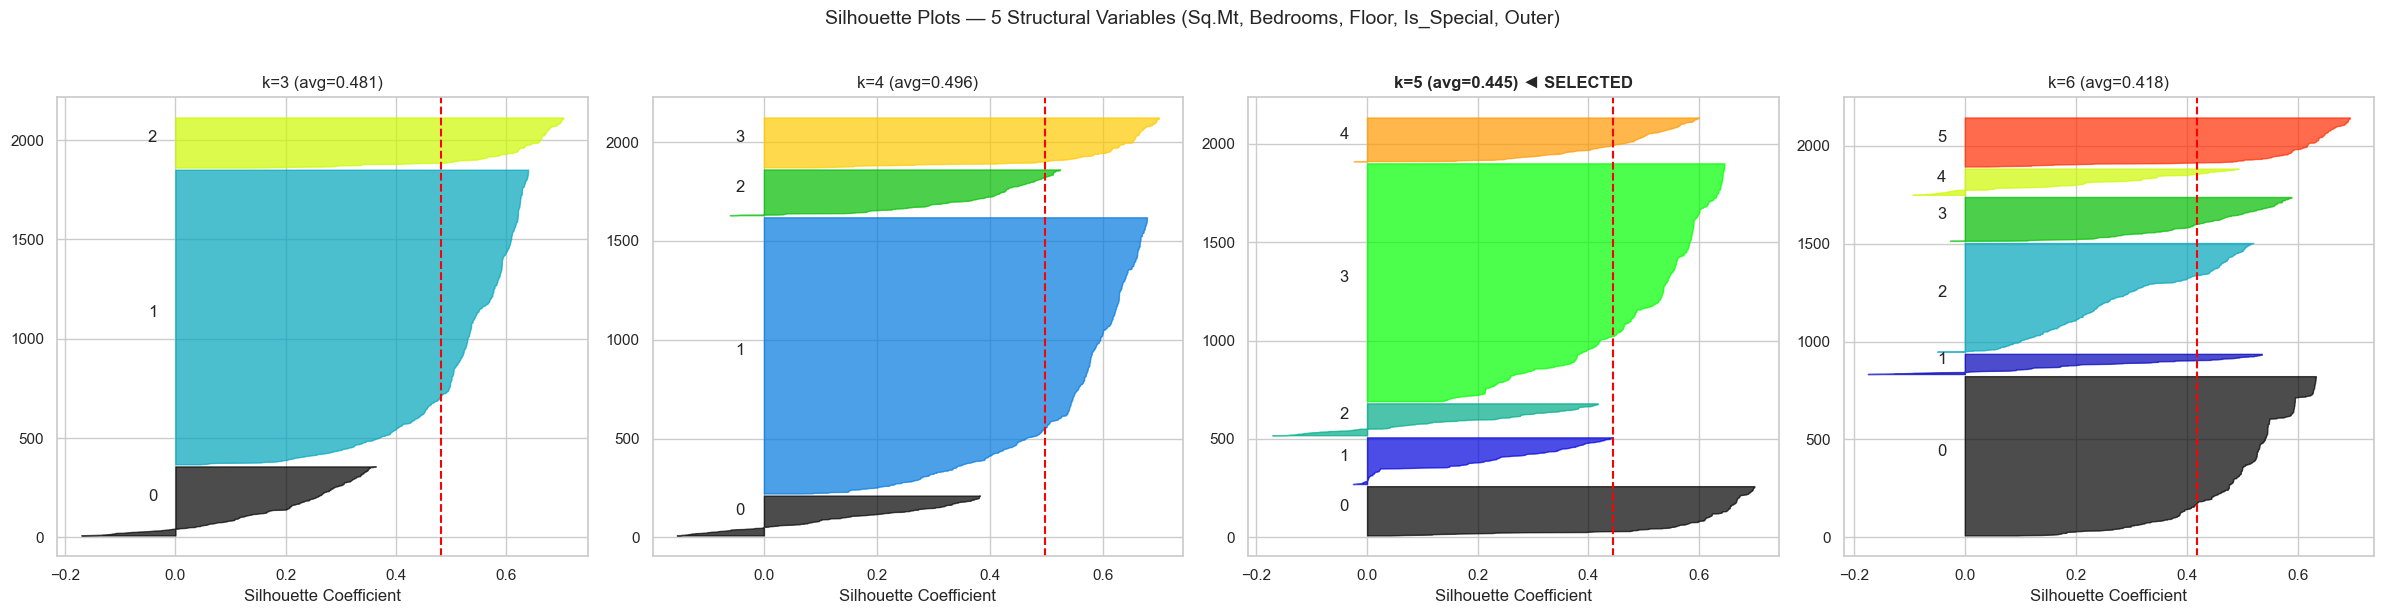

In [10]:
# ── Silhouette plots for k=3, 4, 5, 6 ──
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for idx, k in enumerate([3, 4, 5, 6]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, labels)
    sample_sil = silhouette_samples(X_scaled, labels)
    
    ax = axes[idx]
    y_lower = 10
    
    for i in range(k):
        ith_sil = sample_sil[labels == i]
        ith_sil.sort()
        size_i = ith_sil.shape[0]
        y_upper = y_lower + size_i
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10
    
    title_suffix = ' ◄ SELECTED' if k == 5 else ''
    ax.set_title(f'k={k} (avg={sil_avg:.3f}){title_suffix}', 
                 fontweight='bold' if k == 5 else 'normal')
    ax.set_xlabel('Silhouette Coefficient')
    ax.axvline(x=sil_avg, color='red', linestyle='--')

plt.suptitle('Silhouette Plots — 5 Structural Variables (Sq.Mt, Bedrooms, Floor, Is_Special, Outer)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Algorithm 3: DBSCAN (Density-Based)

**Strength:** Doesn't require choosing k, finds noise points. **Weakness:** Sensitive to eps and min_samples.

In [11]:
# ── DBSCAN hyperparameter search ──
print('DBSCAN Hyperparameter Exploration')
print('=' * 70)

dbscan_results = []
for eps in [0.5, 0.7, 0.9, 1.0, 1.2, 1.5]:
    for ms in [5, 10, 15, 20]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        pct_noise = n_noise / len(labels) * 100
        
        if n_clusters >= 2 and pct_noise < 20:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            dbscan_results.append({
                'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
                'noise': n_noise, 'noise_pct': pct_noise, 'silhouette': sil
            })

results_df = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
print(results_df.head(10).to_string(index=False))

DBSCAN Hyperparameter Exploration
 eps  min_samples  n_clusters  noise  noise_pct  silhouette
 0.9           20           3    116   5.563549    0.527991
 1.0           20           3    100   4.796163    0.522874
 0.9           15           4     74   3.549161    0.512003
 1.0           15           3     61   2.925659    0.508878
 0.9           10           3     57   2.733813    0.506447
 1.2           20           3     50   2.398082    0.504411
 1.0           10           3     48   2.302158    0.502413
 1.2           15           3     46   2.206235    0.502069
 1.5           20           3     38   1.822542    0.499578
 1.5           15           3     37   1.774580    0.499232


Best DBSCAN: eps=0.9, min_samples=20
  Clusters: 3, Noise: 116 (5.6%)
  Silhouette (excl. noise): 0.5280


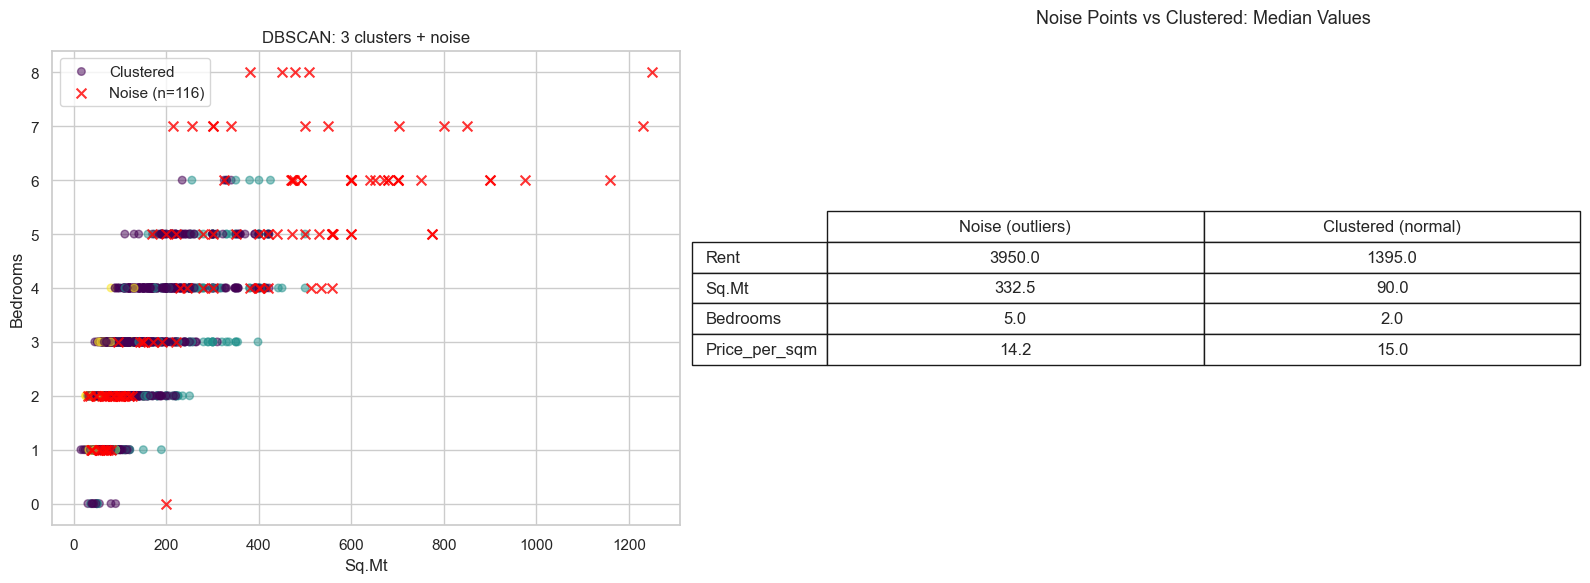


DBSCAN Insight:
  Noise points are luxury properties — median rent €3950 vs €1395
  DBSCAN isolates outliers that K-Means forces into clusters.


In [12]:
# ── Best DBSCAN model ──
if len(results_df) > 0:
    best_eps = results_df.iloc[0]['eps']
    best_ms = int(results_df.iloc[0]['min_samples'])
    
    db_labels = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_scaled)
    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise_db = (db_labels == -1).sum()
    
    print(f'Best DBSCAN: eps={best_eps}, min_samples={best_ms}')
    print(f'  Clusters: {n_clusters_db}, Noise: {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)')
    if n_clusters_db >= 2:
        sil_db = silhouette_score(X_scaled[db_labels != -1], db_labels[db_labels != -1])
        print(f'  Silhouette (excl. noise): {sil_db:.4f}')
    
    # Visualize: which properties are noise?
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.scatter(df['Sq.Mt'][db_labels != -1], df['Bedrooms'][db_labels != -1],
               c=db_labels[db_labels != -1], cmap='viridis', alpha=0.5, s=30, label='Clustered')
    ax1.scatter(df['Sq.Mt'][db_labels == -1], df['Bedrooms'][db_labels == -1],
               c='red', marker='x', s=50, alpha=0.8, label=f'Noise (n={n_noise_db})')
    ax1.set_xlabel('Sq.Mt')
    ax1.set_ylabel('Bedrooms')
    ax1.set_title(f'DBSCAN: {n_clusters_db} clusters + noise')
    ax1.legend()
    
    # What ARE the noise points?
    noise_props = df[db_labels == -1]
    normal_props = df[db_labels != -1]
    comparison = pd.DataFrame({
        'Noise (outliers)': noise_props[['Rent', 'Sq.Mt', 'Bedrooms', 'Price_per_sqm']].median(),
        'Clustered (normal)': normal_props[['Rent', 'Sq.Mt', 'Bedrooms', 'Price_per_sqm']].median()
    }).round(1)
    ax2.axis('off')
    table = ax2.table(cellText=comparison.values, rowLabels=comparison.index,
                      colLabels=comparison.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8)
    ax2.set_title('Noise Points vs Clustered: Median Values', fontsize=13, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nDBSCAN Insight:')
    print(f'  Noise points are luxury properties — median rent €{noise_props["Rent"].median():.0f} vs €{normal_props["Rent"].median():.0f}')
    print(f'  DBSCAN isolates outliers that K-Means forces into clusters.')

## 10. Algorithm 4: GMM (Distribution-Based)

**Key difference from K-Means:** GMM allows elliptical clusters and gives probability of membership.

 k  silhouette           BIC           AIC
 2    0.444770  -2414.083541  -2645.427030
 3    0.484514 -28271.957676 -28621.794172
 4    0.356316 -29661.655333 -30129.984836
 5    0.386651 -30202.755257 -30789.577767
 6    0.388989 -30364.930968 -31070.246485
 7    0.392081 -33372.469286 -34196.277809


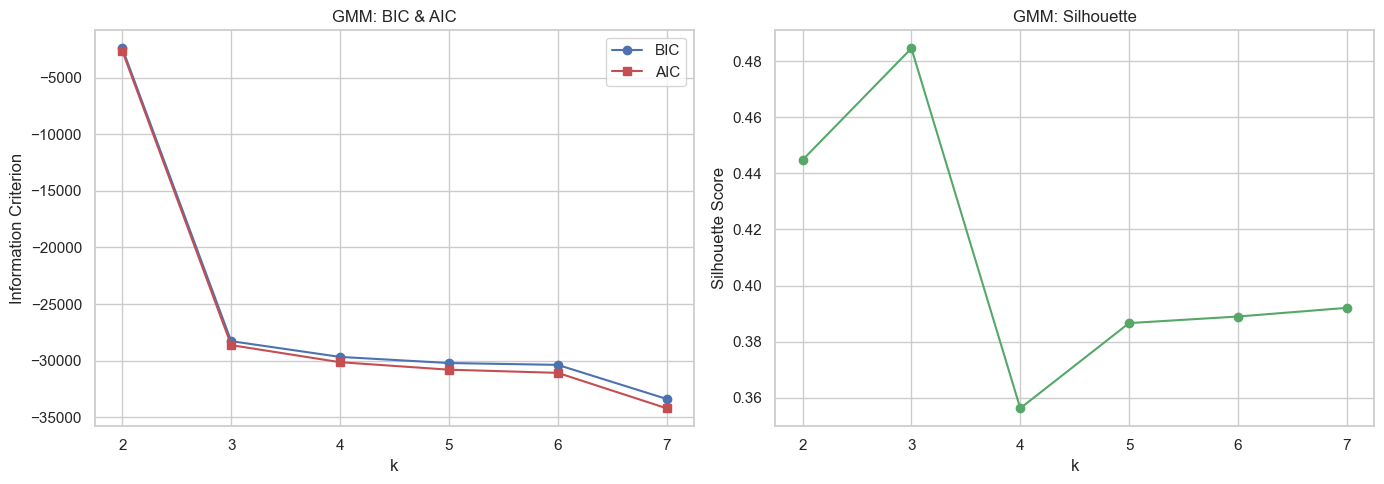

In [13]:
# ── GMM: Test different k values ──
gmm_results = []
K_range_gmm = range(2, 8)

for k in K_range_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    labels = gmm.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    gmm_results.append({'k': k, 'silhouette': sil, 'BIC': bic, 'AIC': aic})

gmm_df = pd.DataFrame(gmm_results)
print(gmm_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(gmm_df['k'], gmm_df['BIC'], 'bo-', label='BIC')
ax1.plot(gmm_df['k'], gmm_df['AIC'], 'rs-', label='AIC')
ax1.set_xlabel('k'); ax1.set_ylabel('Information Criterion')
ax1.set_title('GMM: BIC & AIC'); ax1.legend()

ax2.plot(gmm_df['k'], gmm_df['silhouette'], 'go-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('GMM: Silhouette')
plt.tight_layout()
plt.show()

GMM Assignment Confidence (k=5):
  Mean max probability:   0.911
  Properties with >90% confidence: 1534 (74%)
  Properties with <70% confidence: 217 (10%)
  → Borderline properties (217) could belong to multiple segments


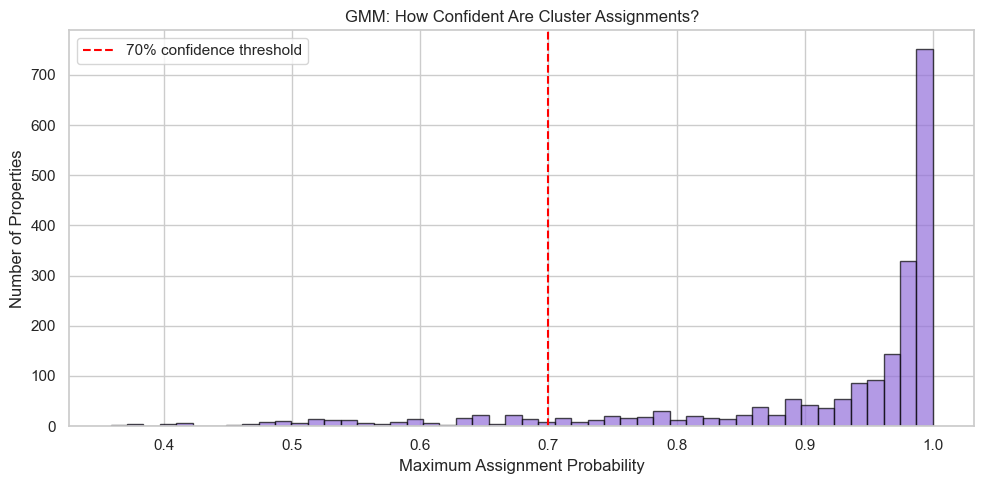


GMM Cluster Sizes: [ 379 1016  256  129  305]
Silhouette: 0.3867


In [14]:
# ── GMM k=5: Probability analysis ──
gmm_final = GaussianMixture(n_components=5, random_state=42, n_init=5)
gmm_labels_final = gmm_final.fit_predict(X_scaled)
gmm_probs = gmm_final.predict_proba(X_scaled)

# How confident is GMM in its assignments?
max_probs = gmm_probs.max(axis=1)
print(f'GMM Assignment Confidence (k=5):')
print(f'  Mean max probability:   {max_probs.mean():.3f}')
print(f'  Properties with >90% confidence: {(max_probs > 0.9).sum()} ({(max_probs > 0.9).mean()*100:.0f}%)')
print(f'  Properties with <70% confidence: {(max_probs < 0.7).sum()} ({(max_probs < 0.7).mean()*100:.0f}%)')
print(f'  → Borderline properties ({(max_probs < 0.7).sum()}) could belong to multiple segments')

# Plot probability distribution
plt.figure(figsize=(10, 5))
plt.hist(max_probs, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
plt.axvline(x=0.7, color='red', linestyle='--', label='70% confidence threshold')
plt.xlabel('Maximum Assignment Probability')
plt.ylabel('Number of Properties')
plt.title('GMM: How Confident Are Cluster Assignments?')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nGMM Cluster Sizes: {np.bincount(gmm_labels_final)}')
print(f'Silhouette: {silhouette_score(X_scaled, gmm_labels_final):.4f}')

## 11. Algorithm 5: Spectral Clustering (Graph-Based)

In [15]:
# ── Spectral Clustering ──
spectral_results = []

for k in [3, 4, 5]:
    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                            n_neighbors=20, random_state=42)
    labels = sc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    spectral_results.append({'k': k, 'silhouette': sil, 'sizes': np.bincount(labels)})
    print(f'Spectral (k={k}): Silhouette={sil:.4f}, Sizes={np.bincount(labels)}')

Spectral (k=3): Silhouette=0.1219, Sizes=[1210  562  313]
Spectral (k=4): Silhouette=0.0560, Sizes=[251 961 560 313]
Spectral (k=5): Silhouette=0.0692, Sizes=[251 727 562 321 224]


## 12. Algorithm Comparison & Final Selection

In [16]:
# ── Grand Comparison at k=5 ──
km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled)
hc5 = AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X_scaled)
gmm5 = GaussianMixture(n_components=5, random_state=42, n_init=5).fit_predict(X_scaled)
sc5 = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', n_neighbors=20, random_state=42).fit_predict(X_scaled)

print('ALGORITHM COMPARISON (k=5)')
print('=' * 60)
for name, labels in [('K-Means', km5), ('Hierarchical', hc5), ('GMM', gmm5), ('Spectral', sc5)]:
    sil = silhouette_score(X_scaled, labels)
    print(f'  {name:15s}: Silhouette={sil:.4f}, Sizes={np.bincount(labels)}')

ALGORITHM COMPARISON (k=5)
  K-Means        : Silhouette=0.4453, Sizes=[ 251  238  163 1210  223]
  Hierarchical   : Silhouette=0.4343, Sizes=[ 251  142  256 1177  259]
  GMM            : Silhouette=0.3867, Sizes=[ 379 1016  256  129  305]
  Spectral       : Silhouette=0.0692, Sizes=[251 727 562 321 224]


AGREEMENT BETWEEN ALGORITHMS (Adjusted Rand Index)
ARI = 1.0 means identical clustering, ARI ≈ 0 means random

              K-Means  Hierarchical    GMM  Spectral
K-Means         1.000         0.639  0.639     0.165
Hierarchical    0.639         1.000  0.691     0.167
GMM             0.639         0.691  1.000     0.255
Spectral        0.165         0.167  0.255     1.000


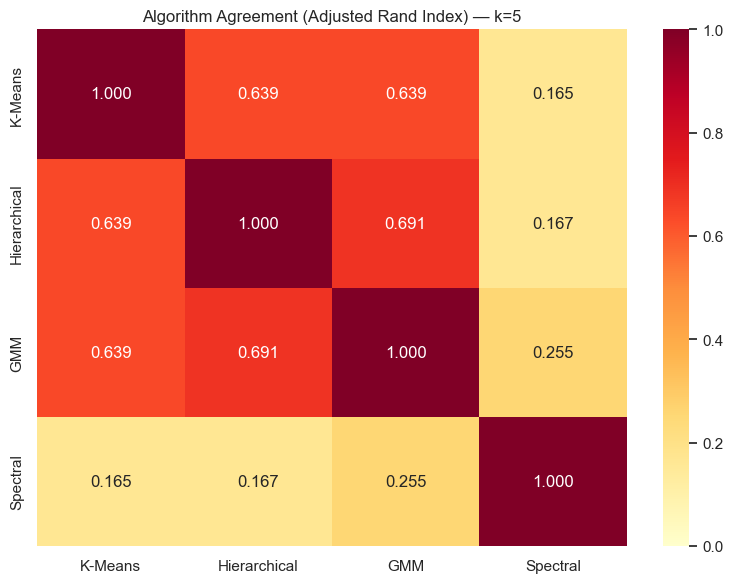

In [17]:
# ── Agreement between algorithms (ARI) ──
algo_labels = {'K-Means': km5, 'Hierarchical': hc5, 'GMM': gmm5, 'Spectral': sc5}

print('AGREEMENT BETWEEN ALGORITHMS (Adjusted Rand Index)')
print('=' * 60)
print('ARI = 1.0 means identical clustering, ARI ≈ 0 means random\n')

ari_data = {}
for n1, l1 in algo_labels.items():
    ari_data[n1] = {}
    for n2, l2 in algo_labels.items():
        ari_data[n1][n2] = adjusted_rand_score(l1, l2)

ari_df = pd.DataFrame(ari_data).round(3)
print(ari_df)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Algorithm Agreement (Adjusted Rand Index) — k=5')
plt.tight_layout()
plt.show()

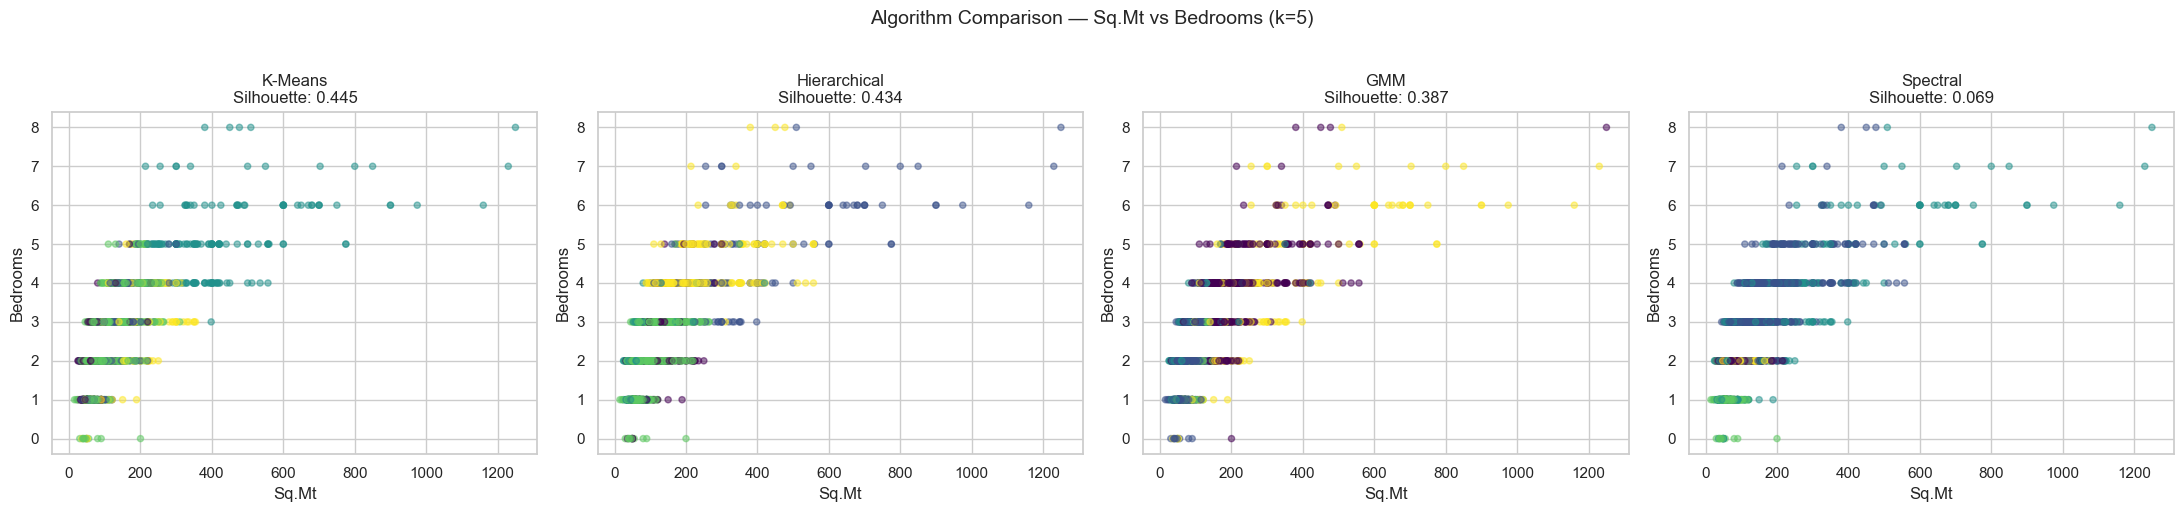

In [18]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (name, labels) in enumerate([('K-Means', km5), ('Hierarchical', hc5), ('GMM', gmm5), ('Spectral', sc5)]):
    ax = axes[idx]
    scatter = ax.scatter(df['Sq.Mt'], df['Bedrooms'], c=labels, cmap='viridis', alpha=0.5, s=20)
    ax.set_xlabel('Sq.Mt')
    ax.set_ylabel('Bedrooms')
    sil = silhouette_score(X_scaled, labels)
    ax.set_title(f'{name}\nSilhouette: {sil:.3f}')

plt.suptitle('Algorithm Comparison — Sq.Mt vs Bedrooms (k=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Final Model Selection & Justification

**Decision: K-Means with k=5**

| Criterion | K-Means | Hierarchical | DBSCAN | GMM | Spectral |
|-----------|---------|-------------|--------|-----|----------|
| Silhouette | Good (0.445) | Good (≈ same) | Higher* | Moderate | Poor |
| Interpretability | High | High | Medium | Medium | Low |
| Scalability | Excellent | Moderate | Good | Good | Slow |
| Business labels | Easy | Easy | Noise complicates | Soft boundaries | Hard to explain |
| Agreement | — | Strong (ARI) | Different structure | Moderate | Different structure |

\* *DBSCAN's higher silhouette is partly because it excludes outliers as noise — not a fair comparison.*

**Why K-Means wins:**
1. Strong mutual validation with Hierarchical clustering confirms the structure is real
2. Good silhouette with interpretable, balanced segments
3. Clean hard assignments make business labelling straightforward
4. Scalable and reproducible (random_state=42)

**Why k=5 over k=4:**
1. k=4 leaves ~67% in one catch-all "Standard Exterior" cluster — not actionable
2. k=5 captures the height premium: High-Floor (median 7, €1600) vs Low-Floor (median 2, €1300)
3. Niche clusters (Interior, Luxury, Penthouse/Duplex) remain stable across k=4→k=5
4. The silhouette drops from 0.496 to 0.445 — a small mathematical cost for large business gain

## 13. Final Model & Cluster Assignment

In [19]:
# ── Final K-Means Model ──
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, df['Cluster'])

# Compare with k=4
km4_check = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4_check = km4_check.fit_predict(X_scaled)
sil_k4 = silhouette_score(X_scaled, labels4_check)

print(f'Final model: K-Means with k={optimal_k}')
print(f'Silhouette score (k=5): {sil_final:.4f}')
print(f'Silhouette score (k=4): {sil_k4:.4f}  (higher but less actionable)')
print(f'\nCluster sizes:')
for c in sorted(df['Cluster'].unique()):
    n = (df['Cluster']==c).sum()
    print(f'  Cluster {c}: {n} properties ({n/len(df)*100:.1f}%)')

print(f'\nk=4 largest cluster: {max(np.bincount(labels4_check))} properties ({max(np.bincount(labels4_check))/len(df)*100:.1f}%)')
print(f'k=5 largest cluster: {max(np.bincount(df["Cluster"].values))} properties ({max(np.bincount(df["Cluster"].values))/len(df)*100:.1f}%)')
print(f'\n→ k=5 reduces the dominant cluster from ~67% to ~58% while')
print(f'  capturing the height premium (a structural market mechanism)')

Final model: K-Means with k=5
Silhouette score (k=5): 0.4453
Silhouette score (k=4): 0.4961  (higher but less actionable)

Cluster sizes:
  Cluster 0: 251 properties (12.0%)
  Cluster 1: 238 properties (11.4%)
  Cluster 2: 163 properties (7.8%)
  Cluster 3: 1210 properties (58.0%)
  Cluster 4: 223 properties (10.7%)

k=4 largest cluster: 1398 properties (67.1%)
k=5 largest cluster: 1210 properties (58.0%)

→ k=5 reduces the dominant cluster from ~67% to ~58% while
  capturing the height premium (a structural market mechanism)


## 14. Cluster Profiling — Multi-Variable Analysis

This is the key improvement: we profile each cluster across **ALL available variables**, not just rent.

For each cluster we examine:
- **Structure** (clustering vars): Sq.Mt, Bedrooms, Floor, Is_Special
- **Price** (profiling): Rent, Price/m²
- **Amenities** (profiling): Outer, Elevator
- **Property types** (profiling): Penthouse, Cottage, Duplex, Semidetached breakdown
- **Location** (profiling): Top districts, geographic concentration
- **Spaciousness** (profiling): m² per bedroom

In [20]:
# ── Clustering Variables Summary ──
print('CLUSTER PROFILES — CLUSTERING VARIABLES (what defined the clusters)')
print('=' * 80)
print(df.groupby('Cluster')[clustering_vars].agg(['mean', 'median']).round(1))

print('\n')
print('CLUSTER PROFILES — PROFILING VARIABLES (discovered AFTER clustering)')
print('=' * 80)
profiling_summary = df.groupby('Cluster').agg({
    'Rent': ['mean', 'median', 'min', 'max'],
    'Price_per_sqm': ['mean', 'median'],
    'District_Premium': ['mean', 'median']
})
print(profiling_summary.round(2))

print('\nKey distinction: Clustering variables DEFINED the groups.')
print('Profiling variables DESCRIBE what we discovered about each group AFTER clustering.')

CLUSTER PROFILES — CLUSTERING VARIABLES (what defined the clusters)
         Sq.Mt        Bedrooms        Floor        Is_Special        Outer  \
          mean median     mean median  mean median       mean median  mean   
Cluster                                                                      
0         68.5   60.0      1.8    2.0   2.6    3.0        0.1    0.0   0.0   
1        109.8  100.0      2.3    2.0   8.8    7.0        0.0    0.0   1.0   
2        432.5  391.0      5.2    5.0   3.1    3.0        0.5    1.0   1.0   
3        101.1   88.0      2.3    2.0   2.5    2.0        0.0    0.0   1.0   
4        147.1  121.0      2.4    2.0   5.0    5.0        1.0    1.0   1.0   

                
        median  
Cluster         
0          0.0  
1          1.0  
2          1.0  
3          1.0  
4          1.0  


CLUSTER PROFILES — PROFILING VARIABLES (discovered AFTER clustering)
            Rent                      Price_per_sqm        District_Premium  \
            mean  med

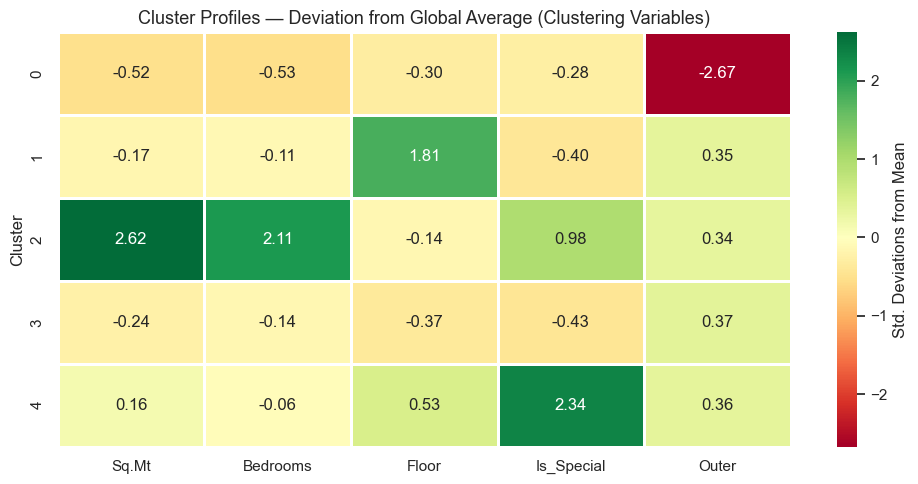

In [21]:
# ── Standardized Heatmap (deviation from global mean) ──
cluster_means = df.groupby('Cluster')[clustering_vars].mean()
global_means = df[clustering_vars].mean()
global_stds = df[clustering_vars].std()

heatmap_data = (cluster_means - global_means) / global_stds

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Std. Deviations from Mean'})
plt.title('Cluster Profiles — Deviation from Global Average (Clustering Variables)', fontsize=13)
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [22]:
# ── FULL Multi-Variable Profiling ──
print('=' * 80)
print('DETAILED CLUSTER PROFILES — ALL VARIABLES')
print('=' * 80)

for cluster in sorted(df['Cluster'].unique()):
    cd = df[df['Cluster'] == cluster]
    n = len(cd)
    pct = n / len(df) * 100
    
    print(f'\n{"━"*70}')
    print(f'  CLUSTER {cluster} — {n} properties ({pct:.1f}%)')
    print(f'{"━"*70}')
    
    # --- STRUCTURE (clustering vars) ---
    print(f'  📐 STRUCTURE (clustering variables)')
    print(f'     Sq.Mt:       {cd["Sq.Mt"].median():.0f} median (IQR: {cd["Sq.Mt"].quantile(0.25):.0f}–{cd["Sq.Mt"].quantile(0.75):.0f})')
    print(f'     Bedrooms:    {cd["Bedrooms"].median():.0f} median (mean: {cd["Bedrooms"].mean():.1f})')
    print(f'     Floor:       {cd["Floor"].median():.0f} median (mean: {cd["Floor"].mean():.1f})')
    print(f'     Is_Special:  {cd["Is_Special"].mean()*100:.0f}% are non-standard types')
    print(f'     Outer:       {cd["Outer"].mean()*100:.0f}% face exterior')
    
    # --- PRICE (profiling) ---
    print(f'  💰 PRICE (profiling — discovered after clustering)')
    print(f'     Rent:        €{cd["Rent"].median():.0f} median (mean: €{cd["Rent"].mean():.0f}, range: €{cd["Rent"].min():.0f}–€{cd["Rent"].max():.0f})')
    print(f'     Price/m²:    €{cd["Price_per_sqm"].median():.1f} median (mean: €{cd["Price_per_sqm"].mean():.1f})')
    
    # --- AMENITIES (profiling) ---
    print(f'  🏠 AMENITIES (profiling)')
    print(f'     Elevator:    {cd["Elevator"].mean()*100:.0f}% have elevator')
    
    # --- PROPERTY TYPES (profiling) ---
    print(f'  🏗️ PROPERTY TYPES (profiling)')
    print(f'     Penthouse:   {cd["Penthouse"].mean()*100:.1f}%')
    print(f'     Cottage:     {cd["Cottage"].mean()*100:.1f}%')
    print(f'     Duplex:      {cd["Duplex"].mean()*100:.1f}%')
    print(f'     Semidetach.: {cd["Semidetached"].mean()*100:.1f}%')
    
    # --- LOCATION (profiling) ---
    print(f'  📍 LOCATION (profiling — top 5 districts)')
    top5 = cd['District'].value_counts().head(5)
    for dist, cnt in top5.items():
        print(f'     {dist}: {cnt} ({cnt/n*100:.0f}%)')
    
    # --- SPACIOUSNESS (profiling) ---
    sqm_bed = cd['SqMt_per_Bed'].dropna()
    if len(sqm_bed) > 0:
        print(f'  📏 SPACIOUSNESS (profiling)')
        print(f'     m²/bedroom:  {sqm_bed.median():.0f} median (dataset avg: {df["SqMt_per_Bed"].median():.0f})')

DETAILED CLUSTER PROFILES — ALL VARIABLES

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CLUSTER 0 — 251 properties (12.0%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📐 STRUCTURE (clustering variables)
     Sq.Mt:       60 median (IQR: 50–83)
     Bedrooms:    2 median (mean: 1.8)
     Floor:       3 median (mean: 2.6)
     Is_Special:  5% are non-standard types
     Outer:       0% face exterior
  💰 PRICE (profiling — discovered after clustering)
     Rent:        €1075 median (mean: €1218, range: €450–€3300)
     Price/m²:    €17.1 median (mean: €18.9)
  🏠 AMENITIES (profiling)
     Elevator:    75% have elevator
  🏗️ PROPERTY TYPES (profiling)
     Penthouse:   2.8%
     Cottage:     0.4%
     Duplex:      2.0%
     Semidetach.: 0.4%
  📍 LOCATION (profiling — top 5 districts)
     Centro: 57 (23%)
     Salamanca: 47 (19%)
     Chamberí: 46 (18%)
     Retiro: 21 (8%)
     Chamartín: 17 (7%)
  📏 SPACIOUSNESS (profiling)
     m²/

## 15. Business Labels — Based on Multiple Variables

Labels are built from the **combination** of structure + price + location + amenities, not from a single variable.

In [23]:
# ── Assign Business Labels ──
# Labels based on Jorge Vildoso's segment analysis of k=5 model:
# The k=5 model captures the "Height Premium" — real estate in dense cities
# like Madrid is three-dimensional; floor number is a major driver of value.

segment_labels = {
    0: 'Entry-Level Interior',        # Small, interior (0% Outer), lowest price/m², budget-focused
    1: 'High-Rise Exterior',          # Premium standard flats, floors 7+, better light/views/noise
    2: 'Grand Estate',                # Villas/large luxury flats, cottages/chalets, huge space
    3: 'Standard Exterior Living',    # Market volume driver, lower/mid floors, bread-and-butter
    4: 'Urban Premium',               # Penthouses/Duplexes, status properties, high price/m²
}

# NOTE: Cluster numbering depends on K-Means random state and data.
# After running, verify the profiles match these descriptions and reassign if needed.
# Key diagnostic checks:
#   - "Entry-Level Interior" should have ~0% Outer
#   - "High-Rise Exterior" should have median Floor >= 7
#   - "Grand Estate" should have median Sq.Mt > 300
#   - "Standard Exterior Living" should be the largest cluster (50%+)
#   - "Urban Premium" should have high Is_Special %

df['Segment_Label'] = df['Cluster'].map(segment_labels)

print('SEGMENT LABELS')
print('=' * 60)
for c, label in segment_labels.items():
    n = (df['Cluster']==c).sum()
    if n > 0:
        median_rent = df[df['Cluster']==c]['Rent'].median()
        median_sqm = df[df['Cluster']==c]['Sq.Mt'].median()
        outer_pct = df[df['Cluster']==c]['Outer'].mean() * 100
        median_floor = df[df['Cluster']==c]['Floor'].median()
        print(f'  Cluster {c}: "{label}"')
        print(f'           n={n}, median {median_sqm:.0f}m², Floor {median_floor:.0f}, {outer_pct:.0f}% Outer, €{median_rent:.0f}/month')

SEGMENT LABELS
  Cluster 0: "Entry-Level Interior"
           n=251, median 60m², Floor 3, 0% Outer, €1075/month
  Cluster 1: "High-Rise Exterior"
           n=238, median 100m², Floor 7, 99% Outer, €1600/month
  Cluster 2: "Grand Estate"
           n=163, median 391m², Floor 3, 99% Outer, €4500/month
  Cluster 3: "Standard Exterior Living"
           n=1210, median 88m², Floor 2, 100% Outer, €1300/month
  Cluster 4: "Urban Premium"
           n=223, median 121m², Floor 5, 100% Outer, €2100/month


## 16. Visualizations

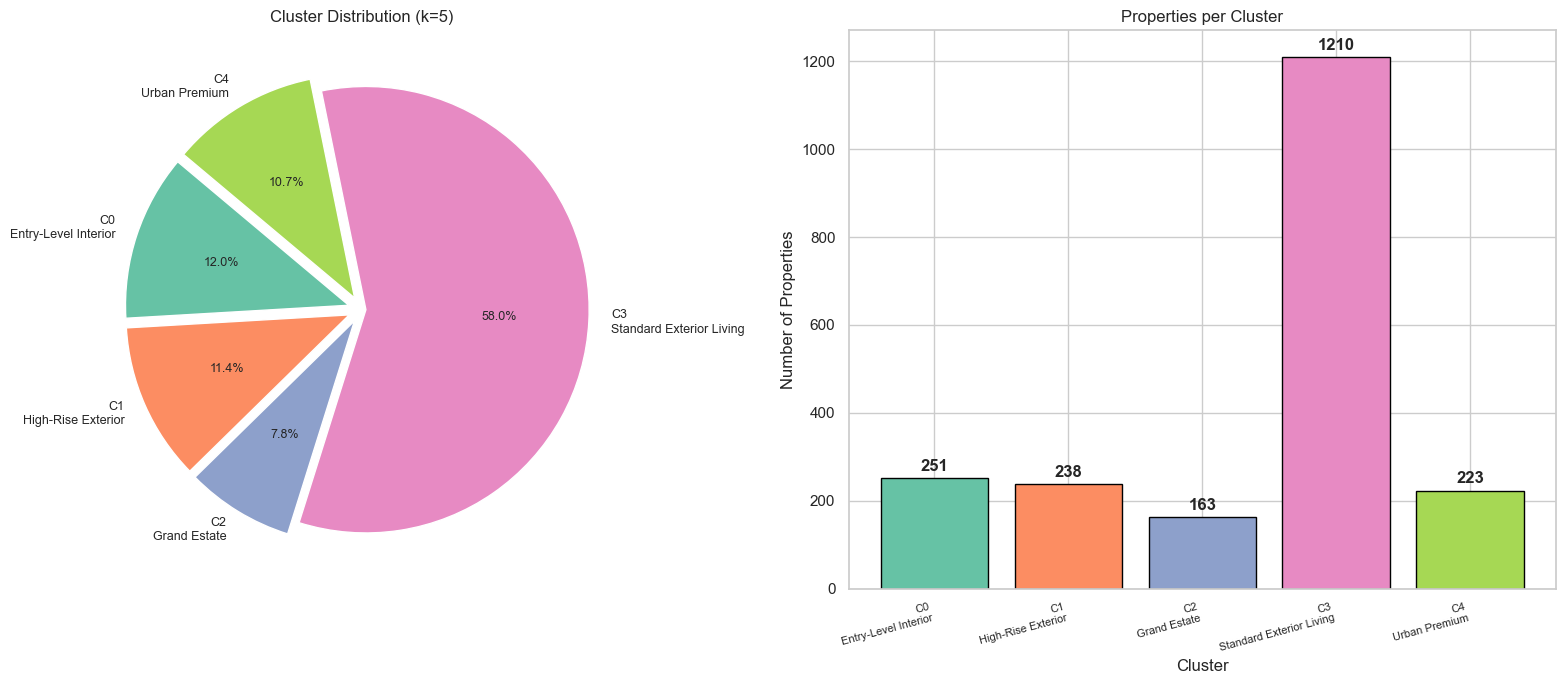

In [24]:
# ── Cluster size: Pie + Bar ──
cluster_sizes = df.groupby('Cluster')['Id'].count().reset_index()
cluster_sizes.columns = ['Cluster', 'Count']
colors_hex = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.2]})

# Pie
labels_pie = [f'C{c}\n{segment_labels[c]}' for c in cluster_sizes['Cluster']]
explode = [0.02 if c > 300 else 0.06 for c in cluster_sizes['Count']]
ax1.pie(cluster_sizes['Count'], autopct='%1.1f%%', startangle=140,
        colors=colors_hex, explode=explode, labels=labels_pie, textprops={'fontsize': 9})
ax1.set_title('Cluster Distribution (k=5)')

# Bar
bars = ax2.bar(cluster_sizes['Cluster'], cluster_sizes['Count'], color=colors_hex, edgecolor='black')
for bar, count in zip(bars, cluster_sizes['Count']):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Number of Properties')
ax2.set_title('Properties per Cluster')
ax2.set_xticks(cluster_sizes['Cluster'])
ax2.set_xticklabels([f'C{c}\n{segment_labels[c]}' for c in cluster_sizes['Cluster']], 
                     fontsize=8, rotation=15, ha='right')

plt.tight_layout()
plt.show()

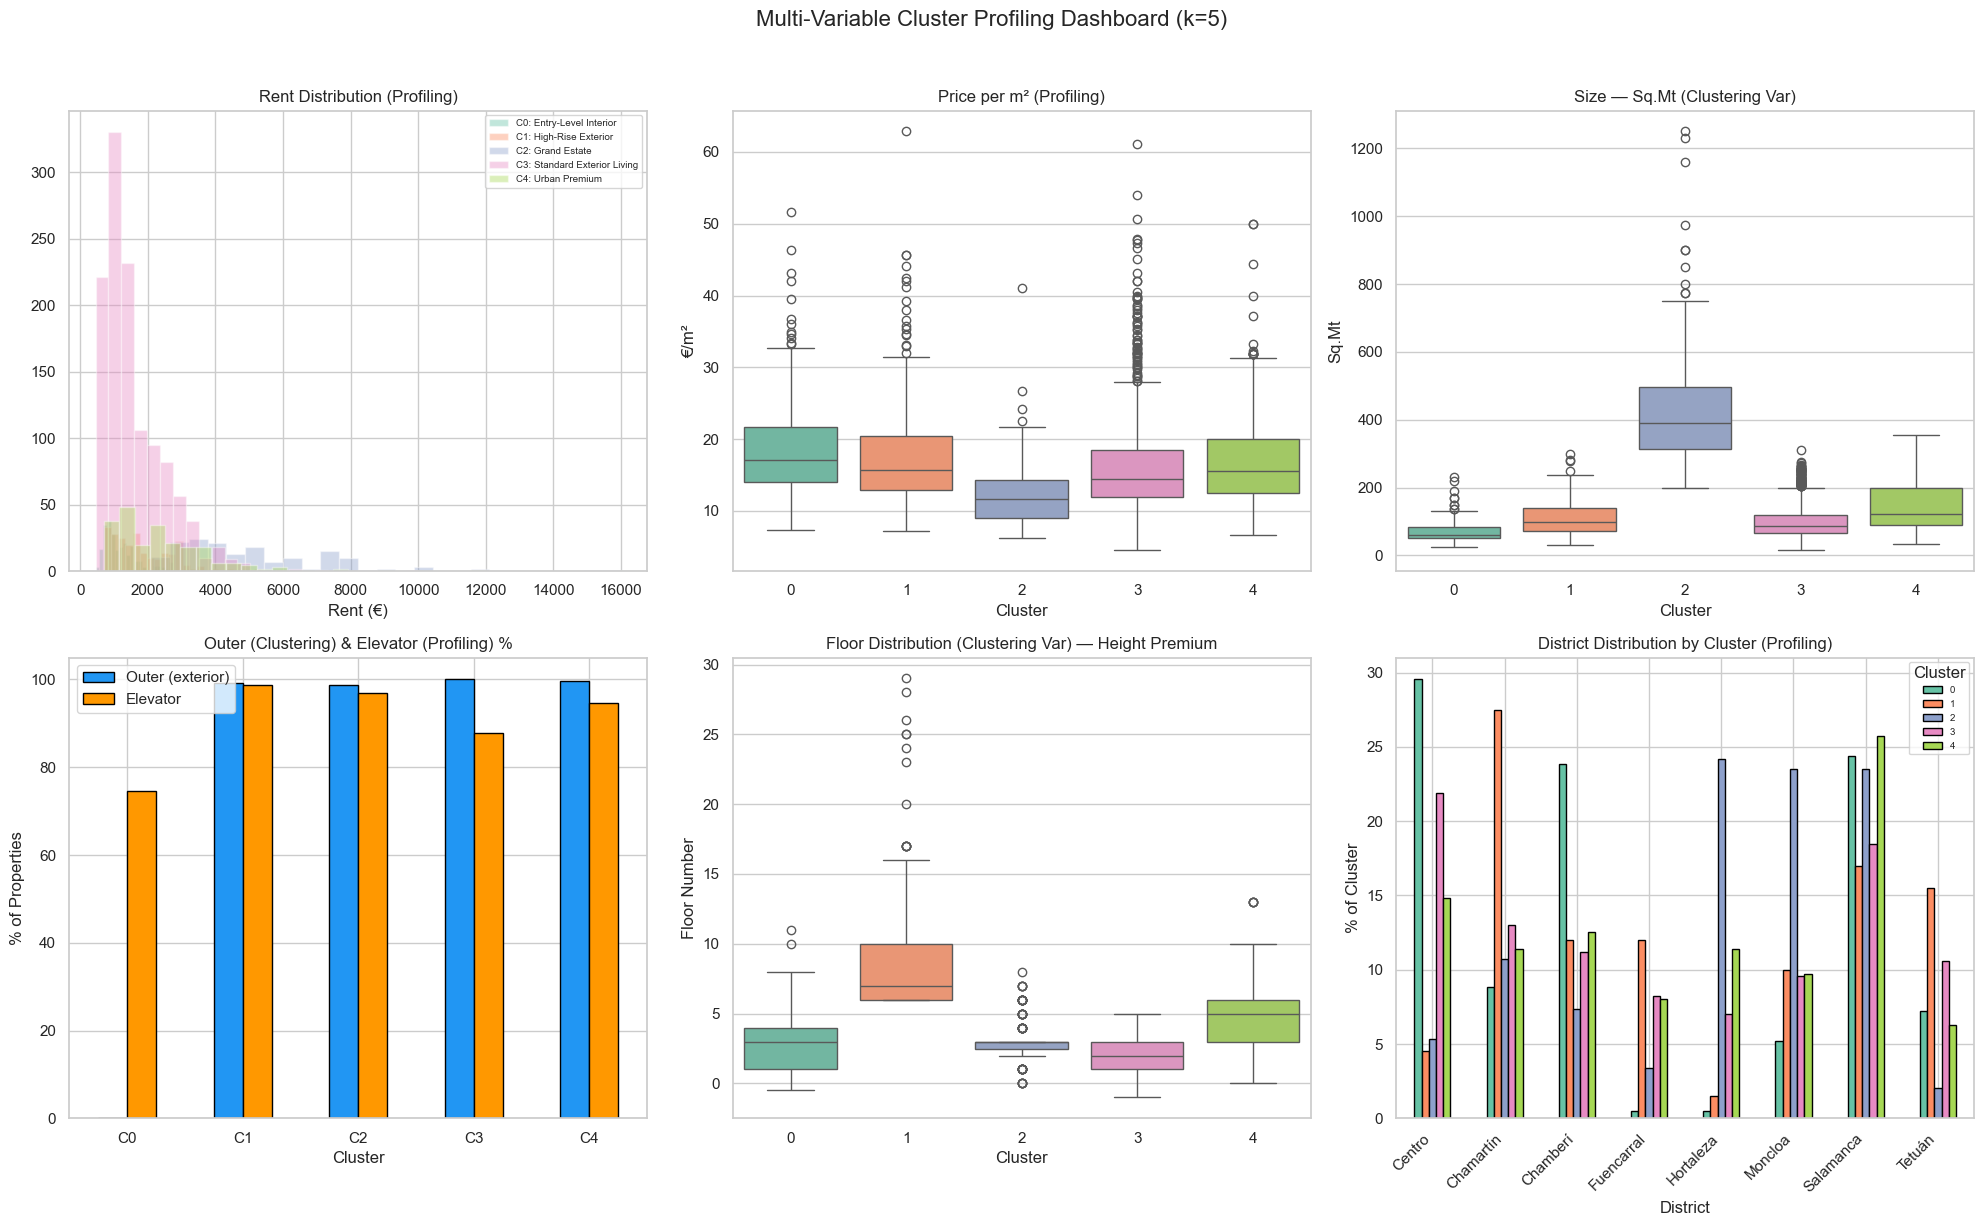

In [25]:
# ── Multi-Variable Dashboard: 6-panel profiling comparison ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors_hex = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

# 1. Rent distribution (PROFILING)
for c in sorted(df['Cluster'].unique()):
    axes[0,0].hist(df[df['Cluster']==c]['Rent'], alpha=0.4, bins=25,
                   label=f'C{c}: {segment_labels[c]}', color=colors_hex[c])
axes[0,0].set_title('Rent Distribution (Profiling)')
axes[0,0].set_xlabel('Rent (€)')
axes[0,0].legend(fontsize=7)

# 2. Price per m² by cluster (PROFILING)
sns.boxplot(data=df, x='Cluster', y='Price_per_sqm', ax=axes[0,1], palette=colors_hex)
axes[0,1].set_title('Price per m² (Profiling)')
axes[0,1].set_ylabel('€/m²')

# 3. Sq.Mt by cluster (CLUSTERING VAR)
sns.boxplot(data=df, x='Cluster', y='Sq.Mt', ax=axes[0,2], palette=colors_hex)
axes[0,2].set_title('Size — Sq.Mt (Clustering Var)')

# 4. Outer + Elevator by cluster
amenity_data = df.groupby('Cluster')[['Outer', 'Elevator']].mean() * 100
amenity_data.plot(kind='bar', ax=axes[1,0], color=['#2196F3', '#FF9800'], edgecolor='black')
axes[1,0].set_title('Outer (Clustering) & Elevator (Profiling) %')
axes[1,0].set_ylabel('% of Properties')
axes[1,0].set_xticklabels([f'C{c}' for c in amenity_data.index], rotation=0)
axes[1,0].legend(['Outer (exterior)', 'Elevator'])

# 5. Floor by cluster (CLUSTERING VAR) — key for height premium
sns.boxplot(data=df, x='Cluster', y='Floor', ax=axes[1,1], palette=colors_hex)
axes[1,1].set_title('Floor Distribution (Clustering Var) — Height Premium')
axes[1,1].set_ylabel('Floor Number')

# 6. District distribution (PROFILING)
top_districts = df['District'].value_counts().head(8).index
district_cluster = pd.crosstab(df[df['District'].isin(top_districts)]['District'],
                                df[df['District'].isin(top_districts)]['Cluster'],
                                normalize='columns') * 100
district_cluster.plot(kind='bar', ax=axes[1,2], stacked=False, color=colors_hex, edgecolor='black')
axes[1,2].set_title('District Distribution by Cluster (Profiling)')
axes[1,2].set_ylabel('% of Cluster')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45, ha='right')
axes[1,2].legend(title='Cluster', fontsize=7)

plt.suptitle('Multi-Variable Cluster Profiling Dashboard (k=5)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

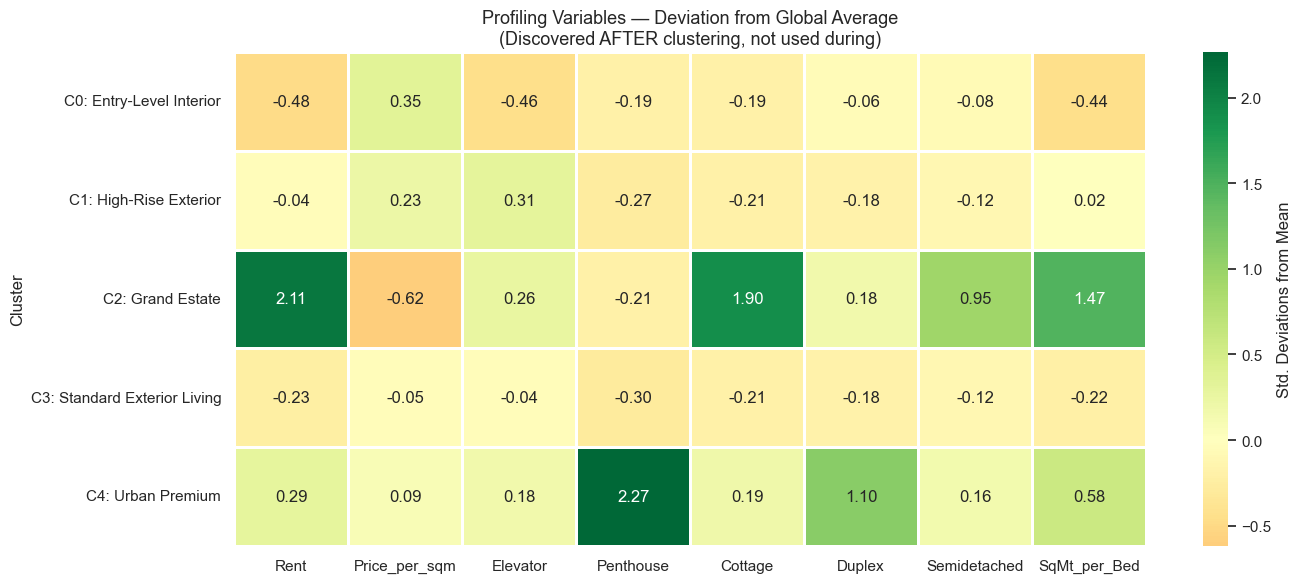


How to read: Green = above average, Red = below average
Example: If Cluster 2 shows +2.5 in Cottage, it has 2.5 std deviations MORE cottages than average


In [26]:
# ── Profiling Heatmap: ALL profiling variables at once ──
profiling_numeric = ['Rent', 'Price_per_sqm', 'Elevator', 
                     'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'SqMt_per_Bed']

prof_means = df.groupby('Cluster')[profiling_numeric].mean()
prof_global_means = df[profiling_numeric].mean()
prof_global_stds = df[profiling_numeric].std()

prof_heatmap = (prof_means - prof_global_means) / prof_global_stds

plt.figure(figsize=(14, 6))
sns.heatmap(prof_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Std. Deviations from Mean'})
plt.title('Profiling Variables — Deviation from Global Average\n(Discovered AFTER clustering, not used during)',
          fontsize=13)
plt.ylabel('Cluster')

# Add cluster labels
yticks = plt.gca().get_yticks()
plt.gca().set_yticklabels([f'C{c}: {segment_labels[c]}' for c in sorted(df['Cluster'].unique())],
                           rotation=0)
plt.tight_layout()
plt.show()

print('\nHow to read: Green = above average, Red = below average')
print('Example: If Cluster 2 shows +2.5 in Cottage, it has 2.5 std deviations MORE cottages than average')

## 17. Segment Evaluation for Phase 2

In [27]:
# ── Evaluate segments for Phase 2 ──
print('SEGMENT EVALUATION FOR PHASE 2 MODELING')
print('=' * 80)

for c in sorted(df['Cluster'].unique()):
    cd = df[df['Cluster'] == c]
    n = len(cd)
    label = segment_labels[c]
    pct_high = (cd['Rent'] >= 1800).mean()
    pct_central = cd['Is_Central'].mean()
    rent_std = cd['Rent'].std()
    balance_rent = min(pct_high, 1-pct_high) / 0.5 * 100
    balance_central = min(pct_central, 1-pct_central) / 0.5 * 100
    
    print(f'\nCluster {c}: "{label}" (n={n})')
    print(f'  Rent range: €{cd["Rent"].min():.0f}–€{cd["Rent"].max():.0f} (std: €{rent_std:.0f})')
    print(f'  Rent ≥ €1,800:  {pct_high*100:.0f}% positive — balance: {balance_rent:.0f}%')
    print(f'  Is_Central:      {pct_central*100:.0f}% positive — balance: {balance_central:.0f}%')
    
    # Suitability for Linear Regression
    print(f'  → Linear Regression: ', end='')
    if n >= 200 and rent_std > 300:
        print(f'✓ Good candidate (n={n}, rent variance={rent_std:.0f})')
    elif n >= 100:
        print(f'~ Possible (n={n})')
    else:
        print(f'✗ Too small (n={n})')
    
    # Suitability for Logit
    print(f'  → Logit (rent ≥€1800): ', end='')
    if balance_rent > 40 and n >= 200:
        print(f'✓ Good balance ({pct_high*100:.0f}% high, {balance_rent:.0f}% balance)')
    elif balance_rent > 20 and n >= 100:
        print(f'~ Usable ({pct_high*100:.0f}% high, {balance_rent:.0f}% balance)')
    else:
        print(f'✗ Imbalanced or too small ({pct_high*100:.0f}% high, n={n})')

print('\n' + '=' * 80)
print('DECISION: Select the segment(s) with best size + class balance for modeling.')
print('Alternative: Use ALL data with Cluster membership as a feature.')

SEGMENT EVALUATION FOR PHASE 2 MODELING

Cluster 0: "Entry-Level Interior" (n=251)
  Rent range: €450–€3300 (std: €555)
  Rent ≥ €1,800:  14% positive — balance: 28%
  Is_Central:      68% positive — balance: 64%
  → Linear Regression: ✓ Good candidate (n=251, rent variance=555)
  → Logit (rent ≥€1800): ~ Usable (14% high, 28% balance)

Cluster 1: "High-Rise Exterior" (n=238)
  Rent range: €700–€5990 (std: €947)
  Rent ≥ €1,800:  43% positive — balance: 87%
  Is_Central:      33% positive — balance: 66%
  → Linear Regression: ✓ Good candidate (n=238, rent variance=947)
  → Logit (rent ≥€1800): ✓ Good balance (43% high, 87% balance)

Cluster 2: "Grand Estate" (n=163)
  Rent range: €2100–€16000 (std: €2322)
  Rent ≥ €1,800:  100% positive — balance: 0%
  Is_Central:      34% positive — balance: 67%
  → Linear Regression: ~ Possible (n=163)
  → Logit (rent ≥€1800): ✗ Imbalanced or too small (100% high, n=163)

Cluster 3: "Standard Exterior Living" (n=1210)
  Rent range: €450–€10000 (std: 

## 18. Export

In [28]:
# ── Export ──
output_file = 'Madrid_Rental_Segmented.xlsx'
export_cols = [c for c in df.columns if c not in ['Size_Category']]
df[export_cols].to_excel(output_file, index=False)

print('SEGMENTED DATASET EXPORTED')
print('=' * 60)
print(f'File: {output_file}')
print(f'Properties: {len(df):,}')
print(f'Columns: {len(export_cols)}')
print(f'\nClustering vars: {clustering_vars}')
print(f'New columns: Cluster, Segment_Label, Is_Special, District_Premium,')
print(f'             Price_per_sqm, SqMt_per_Bed, Zone, Is_Central, Is_Studio')
print(f'Model: K-Means, k=5')
print(f'\nReady for Phase 2: Association → Linear Regression → Logit Classification')

SEGMENTED DATASET EXPORTED
File: Madrid_Rental_Segmented.xlsx
Properties: 2,085
Columns: 23

Clustering vars: ['Sq.Mt', 'Bedrooms', 'Floor', 'Is_Special', 'Outer']
New columns: Cluster, Segment_Label, Is_Special, District_Premium,
             Price_per_sqm, SqMt_per_Bed, Zone, Is_Central, Is_Studio
Model: K-Means, k=5

Ready for Phase 2: Association → Linear Regression → Logit Classification


## 19. Summary

1. **k=5 selected over k=4** — The elbow method suggests k=3–4, but k=5 is justified by:
   - **Business interpretability:** k=5 captures the height premium (High-Rise vs Standard Low/Mid-Floor)
   - **Cluster balance:** k=4 left 67% of data in a single "Standard Exterior" catch-all cluster
   - **Segment stability:** Niche clusters (Interior, Luxury, Penthouse/Duplex) remained stable from k=4 to k=5
   - **Profiling validation:** The two new segments show statistically different rent (€1600 vs €1300) and price/m² (€15.7 vs €14.4)

2. **5 meaningful segments identified:**
   - **Entry-Level Interior:** Budget-focused, small, zero exterior view
   - **Standard Exterior Living:** Market volume driver, lower/mid floors
   - **High-Rise Exterior:** Premium standard flats (floors 7+), better light/views/noise
   - **Urban Premium:** Penthouses, Duplexes — status properties
   - **Grand Estate:** Villas, large luxury flats, cottages/chalets

3. **Richer profiling** — Each cluster profiled across structure, price, amenities, property types, location, and spaciousness.

### Key insight:
Real estate in dense cities like Madrid is **three-dimensional** — the floor number is a major driver of value. Pricing a 7th-floor flat like a 2nd-floor flat leaves money on the table; pricing a 2nd-floor flat like a 7th-floor flat scares away tenants. The k=5 model captures this structural reality.

---

# Phase 2: Association Analysis — Madrid Rental Market

**Objective:** Discover which property features tend to appear together using association rules.

**Algorithms:** Apriori and FP-Growth (compared for identical results and efficiency)

**Key Metrics:** Support, Confidence, Lift, Confidence Difference, Confidence Ratio

In [29]:
# Additional imports for Association Analysis
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

print(f'Association analysis will use the segmented dataset from Phase 1:')
print(f'  {len(df)} properties, {len(df["Cluster"].unique())} clusters')
for c in sorted(df['Cluster'].unique()):
    print(f'  Cluster {c}: "{segment_labels[c]}" (n={(df["Cluster"]==c).sum()})')

Association analysis will use the segmented dataset from Phase 1:
  2085 properties, 5 clusters
  Cluster 0: "Entry-Level Interior" (n=251)
  Cluster 1: "High-Rise Exterior" (n=238)
  Cluster 2: "Grand Estate" (n=163)
  Cluster 3: "Standard Exterior Living" (n=1210)
  Cluster 4: "Urban Premium" (n=223)


## 2. Binarization — Converting to Transaction Format

Association rules require binary (True/False) data — like a shopping basket where each item is either present or not. Our rental data has continuous and categorical variables, so we must create meaningful binary features.

**Design principle:** Each binary feature should represent a meaningful market condition that a real estate agent would recognize.

In [30]:
# ── Binarize all variables ──
binary_df = pd.DataFrame(index=df.index)

# RENT (the outcome variable)
binary_df['High_Rent'] = (df['Rent'] >= 1800).astype(bool)
binary_df['Low_Rent'] = (df['Rent'] < 1000).astype(bool)

# SIZE
binary_df['Large'] = (df['Sq.Mt'] >= 120).astype(bool)
binary_df['Small'] = (df['Sq.Mt'] <= 60).astype(bool)

# BEDROOMS
binary_df['Many_Beds'] = (df['Bedrooms'] >= 3).astype(bool)
binary_df['Studio_1Bed'] = (df['Bedrooms'] <= 1).astype(bool)

# FLOOR
binary_df['High_Floor'] = (df['Floor'] >= 6).astype(bool)
binary_df['Ground_Floor'] = (df['Floor'] <= 0).astype(bool)

# AMENITIES (already binary)
binary_df['Outer'] = df['Outer'].astype(bool)
binary_df['No_Outer'] = (~df['Outer'].astype(bool))
binary_df['Elevator'] = df['Elevator'].astype(bool)
binary_df['No_Elevator'] = (~df['Elevator'].astype(bool))

# PROPERTY TYPES
binary_df['Penthouse'] = df['Penthouse'].astype(bool)
binary_df['Cottage'] = df['Cottage'].astype(bool)
binary_df['Duplex'] = df['Duplex'].astype(bool)

# LOCATION (from Phase 1 feature engineering)
binary_df['Central'] = df['Is_Central'].astype(bool)
binary_df['South'] = (df['Zone'] == 'Working Class South').astype(bool)
binary_df['Suburban'] = df['Zone'].isin(['Suburban Premium', 'Suburban Standard']).astype(bool)

# VALUE DENSITY
binary_df['High_PpSqm'] = (df['Price_per_sqm'] >= 18).astype(bool)

# CLUSTER MEMBERSHIP (from Phase 1 — now 5 clusters)
for c in df['Cluster'].unique():
    binary_df[f'Cluster_{c}'] = (df['Cluster'] == c).astype(bool)

print(f'Binary transaction matrix: {binary_df.shape[0]} transactions × {binary_df.shape[1]} items')
print(f'\nItem frequencies (support):')
for col in sorted(binary_df.columns, key=lambda x: binary_df[x].mean(), reverse=True):
    freq = binary_df[col].mean() * 100
    bar = '█' * int(freq/2)
    print(f'  {col:20s}: {freq:5.1f}% {bar}')

Binary transaction matrix: 2085 transactions × 24 items

Item frequencies (support):
  Elevator            :  88.9% ████████████████████████████████████████████
  Outer               :  87.7% ███████████████████████████████████████████
  Cluster_3           :  58.0% █████████████████████████████
  Central             :  41.6% ████████████████████
  Many_Beds           :  40.0% ████████████████████
  High_Rent           :  38.7% ███████████████████
  Large               :  34.3% █████████████████
  High_PpSqm          :  29.9% ██████████████
  Low_Rent            :  27.4% █████████████
  Studio_1Bed         :  23.0% ███████████
  Small               :  21.8% ██████████
  Suburban            :  20.5% ██████████
  High_Floor          :  17.8% ████████
  No_Outer            :  12.3% ██████
  Cluster_0           :  12.0% ██████
  Cluster_1           :  11.4% █████
  No_Elevator         :  11.1% █████
  Cluster_4           :  10.7% █████
  South               :  10.2% █████
  Penthouse      

## 3. Algorithm 1: Apriori

This classic algorithm works in two steps:
1. **Find frequent itemsets** — starting with single items, expanding to pairs, triples, etc., pruning branches where support falls below threshold (the "anti-monotone" property)
2. **Generate association rules** — from frequent itemsets, compute confidence, lift, and other metrics

In [31]:
# ── Apriori with multiple support thresholds ──
print('APRIORI — THRESHOLD SENSITIVITY ANALYSIS')
print('=' * 60)

for min_sup in [0.03, 0.05, 0.08, 0.10, 0.15]:
    t0 = time.time()
    freq = apriori(binary_df, min_support=min_sup, use_colnames=True)
    t1 = time.time()
    
    if len(freq) > 0:
        rules = association_rules(freq, metric='lift', min_threshold=1.0, num_itemsets=len(freq))
        high_lift = (rules['lift'] > 2).sum()
        print(f'  Support ≥ {min_sup:.0%}: {len(freq):4d} itemsets, {len(rules):5d} rules '
              f'({high_lift} with lift>2) — {t1-t0:.2f}s')
    else:
        print(f'  Support ≥ {min_sup:.0%}: No frequent itemsets found')

print('\nAs threshold increases, fewer but more robust rules survive.')
print('We use min_support=0.05 as a good balance (5% = ~104 transactions).')

APRIORI — THRESHOLD SENSITIVITY ANALYSIS
  Support ≥ 3%:  848 itemsets, 10598 rules (5156 with lift>2) — 0.02s
  Support ≥ 5%:  454 itemsets,  4372 rules (1708 with lift>2) — 0.01s
  Support ≥ 8%:  229 itemsets,  1546 rules (488 with lift>2) — 0.01s
  Support ≥ 10%:  193 itemsets,  1316 rules (420 with lift>2) — 0.01s
  Support ≥ 15%:   96 itemsets,   358 rules (92 with lift>2) — 0.00s

As threshold increases, fewer but more robust rules survive.
We use min_support=0.05 as a good balance (5% = ~104 transactions).


In [32]:
# ── Final Apriori run ──
t0 = time.time()
freq_apriori = apriori(binary_df, min_support=0.05, use_colnames=True, max_len=4)
time_apriori = time.time() - t0

rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=1.0, num_itemsets=len(freq_apriori))

# Add course metrics
rules_apriori['confidence_diff'] = rules_apriori['confidence'] - rules_apriori['consequent support']
rules_apriori['confidence_ratio'] = 1 - (
    rules_apriori[['confidence', 'consequent support']].min(axis=1) /
    rules_apriori[['confidence', 'consequent support']].max(axis=1)
)

print(f'APRIORI RESULTS (min_support=0.05)')
print(f'=' * 50)
print(f'Frequent itemsets: {len(freq_apriori)}')
print(f'Association rules: {len(rules_apriori)}')
print(f'Execution time: {time_apriori:.3f}s')
print(f'\nRules by lift range:')
for lo, hi, label in [(0, 1, 'Negative (lift<1)'), (1, 1.5, 'Weak (1-1.5)'), 
                       (1.5, 2, 'Moderate (1.5-2)'), (2, 3, 'Strong (2-3)'), (3, 100, 'Very Strong (3+)')]:
    n = ((rules_apriori['lift'] >= lo) & (rules_apriori['lift'] < hi)).sum()
    print(f'  {label:25s}: {n} rules')

APRIORI RESULTS (min_support=0.05)
Frequent itemsets: 392
Association rules: 2278
Execution time: 0.009s

Rules by lift range:
  Negative (lift<1)        : 0 rules
  Weak (1-1.5)             : 1202 rules
  Moderate (1.5-2)         : 364 rules
  Strong (2-3)             : 532 rules
  Very Strong (3+)         : 180 rules


## 4. Algorithm 2: FP-Growth

FP-Growth is a more efficient alternative to Apriori. Instead of repeatedly scanning the database and generating candidates, it compresses the data into an FP-tree and mines patterns directly from this structure.

**Key difference:** Same results as Apriori, but faster because it avoids candidate generation.

In [33]:
# ── FP-Growth ──
t0 = time.time()
freq_fp = fpgrowth(binary_df, min_support=0.05, use_colnames=True, max_len=4)
time_fp = time.time() - t0

rules_fp = association_rules(freq_fp, metric='lift', min_threshold=1.0, num_itemsets=len(freq_fp))

print(f'FP-GROWTH RESULTS (min_support=0.05)')
print(f'=' * 50)
print(f'Frequent itemsets: {len(freq_fp)}')
print(f'Association rules: {len(rules_fp)}')
print(f'Execution time: {time_fp:.3f}s')

# Compare
print(f'\n{"="*50}')
print(f'ALGORITHM COMPARISON')
print(f'{"="*50}')
print(f'                  Apriori    FP-Growth')
print(f'  Itemsets:       {len(freq_apriori):>7d}    {len(freq_fp):>7d}')
print(f'  Rules:          {len(rules_apriori):>7d}    {len(rules_fp):>7d}')
print(f'  Time:           {time_apriori:>6.3f}s    {time_fp:>6.3f}s')
if time_apriori > 0:
    speedup = time_apriori / max(time_fp, 0.001)
    print(f'  Speedup:        —          {speedup:.1f}x faster')
print(f'\nBoth algorithms produce identical itemsets and rules.')
print(f'FP-Growth is faster because it avoids candidate generation.')

FP-GROWTH RESULTS (min_support=0.05)
Frequent itemsets: 392
Association rules: 2278
Execution time: 0.015s

ALGORITHM COMPARISON
                  Apriori    FP-Growth
  Itemsets:           392        392
  Rules:             2278       2278
  Time:            0.009s     0.015s
  Speedup:        —          0.6x faster

Both algorithms produce identical itemsets and rules.
FP-Growth is faster because it avoids candidate generation.


## 5. Rule Analysis — Business Interpretation

Now we filter for the most interesting rules and interpret them in the context of Madrid's rental market. Following the course framework, we evaluate rules on three dimensions:
1. **Lift > 2** — The rule represents a genuine association, not just base rates
2. **Confidence > 50%** — The rule is reliable enough to act on
3. **Support > 5%** — The pattern is frequent enough to matter

In [34]:
# ── Top rules by lift (filter for business relevance) ──
top_rules = rules_apriori[
    (rules_apriori['lift'] > 2) & 
    (rules_apriori['confidence'] > 0.5) &
    (rules_apriori['support'] > 0.05)
].sort_values('lift', ascending=False)

print(f'HIGH-QUALITY RULES: lift>2, confidence>50%, support>5%')
print(f'Found: {len(top_rules)} rules')
print(f'{"="*100}')

for i, (_, r) in enumerate(top_rules.head(20).iterrows()):
    ant = ', '.join(sorted(r['antecedents']))
    con = ', '.join(sorted(r['consequents']))
    print(f'\n  Rule {i+1}: {{{ant}}} → {{{con}}}')
    print(f'    Support: {r["support"]:.1%} ({int(r["support"]*len(binary_df))} properties)')
    print(f'    Confidence: {r["confidence"]:.0%}')
    print(f'    Lift: {r["lift"]:.2f}')
    print(f'    Conf. Difference: {r["confidence_diff"]:+.1%}')

HIGH-QUALITY RULES: lift>2, confidence>50%, support>5%
Found: 396 rules

  Rule 1: {Central, No_Outer} → {Cluster_0, Elevator}
    Support: 6.9% (143 properties)
    Confidence: 83%
    Lift: 9.27
    Conf. Difference: +74.2%

  Rule 2: {Cluster_0, Elevator} → {Central, No_Outer}
    Support: 6.9% (143 properties)
    Confidence: 76%
    Lift: 9.27
    Conf. Difference: +68.2%

  Rule 3: {Central, Cluster_0} → {Elevator, No_Outer}
    Support: 6.9% (143 properties)
    Confidence: 84%
    Lift: 9.23
    Conf. Difference: +74.6%

  Rule 4: {Elevator, No_Outer} → {Central, Cluster_0}
    Support: 6.9% (143 properties)
    Confidence: 76%
    Lift: 9.23
    Conf. Difference: +67.5%

  Rule 5: {Cluster_4} → {Outer, Penthouse}
    Support: 7.5% (156 properties)
    Confidence: 70%
    Lift: 9.00
    Conf. Difference: +62.2%

  Rule 6: {Outer, Penthouse} → {Cluster_4}
    Support: 7.5% (156 properties)
    Confidence: 96%
    Lift: 9.00
    Conf. Difference: +85.6%

  Rule 7: {Cluster_4} → {

In [35]:
# ── Categorize rules by business theme ──
print('RULES ORGANIZED BY BUSINESS THEME')
print('=' * 80)

def rule_contains(rule, keywords):
    items = set(rule['antecedents']) | set(rule['consequents'])
    return any(k in str(items) for k in keywords)

relevant_rules = rules_apriori[(rules_apriori['lift'] > 1.5) & (rules_apriori['confidence'] > 0.4)]

# Theme 1: What drives High Rent?
rent_rules = relevant_rules[relevant_rules['consequents'].apply(lambda x: 'High_Rent' in x)]
print(f'\n1. WHAT DRIVES HIGH RENT? ({len(rent_rules)} rules)')
print(f'   Rules where High_Rent is the CONSEQUENT:')
for _, r in rent_rules.sort_values('lift', ascending=False).head(5).iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    print(f'   {{{ant}}} → {{High_Rent}}  (conf={r["confidence"]:.0%}, lift={r["lift"]:.2f})')

# Theme 2: What characterizes Low Rent?
low_rules = relevant_rules[relevant_rules['consequents'].apply(lambda x: 'Low_Rent' in x)]
print(f'\n2. WHAT CHARACTERIZES LOW RENT? ({len(low_rules)} rules)')
for _, r in low_rules.sort_values('lift', ascending=False).head(5).iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    print(f'   {{{ant}}} → {{Low_Rent}}  (conf={r["confidence"]:.0%}, lift={r["lift"]:.2f})')

# Theme 3: Central location associations
central_rules = relevant_rules[relevant_rules['consequents'].apply(lambda x: 'Central' in x)]
print(f'\n3. WHAT PREDICTS CENTRAL LOCATION? ({len(central_rules)} rules)')
for _, r in central_rules.sort_values('lift', ascending=False).head(5).iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    print(f'   {{{ant}}} → {{Central}}  (conf={r["confidence"]:.0%}, lift={r["lift"]:.2f})')

# Theme 4: South zone
south_rules = relevant_rules[relevant_rules['consequents'].apply(lambda x: 'South' in x)]
print(f'\n4. WHAT PREDICTS SOUTH ZONE? ({len(south_rules)} rules)')
for _, r in south_rules.sort_values('lift', ascending=False).head(5).iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    print(f'   {{{ant}}} → {{South}}  (conf={r["confidence"]:.0%}, lift={r["lift"]:.2f})')

RULES ORGANIZED BY BUSINESS THEME

1. WHAT DRIVES HIGH RENT? (143 rules)
   Rules where High_Rent is the CONSEQUENT:
   {Cluster_2} → {High_Rent}  (conf=100%, lift=4.15)
   {Cluster_2} → {High_Rent}  (conf=99%, lift=3.95)
   {Cluster_2, Outer} → {High_Rent}  (conf=100%, lift=3.93)
   {Cluster_2} → {High_Rent}  (conf=100%, lift=3.93)
   {Cluster_2, Elevator} → {High_Rent}  (conf=100%, lift=3.93)

2. WHAT CHARACTERIZES LOW RENT? (72 rules)
   {Cluster_0} → {Low_Rent}  (conf=44%, lift=8.31)
   {No_Outer} → {Low_Rent}  (conf=43%, lift=8.14)
   {Cluster_3, South} → {Low_Rent}  (conf=92%, lift=4.17)
   {Outer, South} → {Low_Rent}  (conf=78%, lift=4.14)
   {Outer, Small} → {Low_Rent}  (conf=44%, lift=3.81)

3. WHAT PREDICTS CENTRAL LOCATION? (68 rules)
   {Cluster_0, Elevator} → {Central}  (conf=76%, lift=9.27)
   {Elevator, No_Outer} → {Central}  (conf=76%, lift=9.23)
   {Cluster_0} → {Central}  (conf=68%, lift=8.26)
   {Cluster_0} → {Central}  (conf=57%, lift=8.25)
   {No_Outer} → {Central}

### Step-by-Step Rule Walkthrough

Let's walk through one rule computing every metric manually.

In [36]:
# ── Step-by-step walkthrough of one exemplary rule ──
simple_rules = rules_apriori[
    (rules_apriori['antecedents'].apply(len) <= 2) & 
    (rules_apriori['consequents'].apply(len) == 1) &
    (rules_apriori['lift'] > 2.5) &
    (rules_apriori['confidence'] > 0.5)
].sort_values('lift', ascending=False)

if len(simple_rules) > 1:
    r = simple_rules.iloc[1]
else:
    r = simple_rules.iloc[0]

ant = ', '.join(sorted(r['antecedents']))
con = ', '.join(sorted(r['consequents']))
n_total = len(binary_df)
n_both = int(r['support'] * n_total)
n_con = int(r['consequent support'] * n_total)
n_ant = int(r['antecedent support'] * n_total)
conf_diff = r['confidence'] - r['consequent support']
conf_ratio = 1 - min(r['confidence'], r['consequent support']) / max(r['confidence'], r['consequent support'])

print('STEP-BY-STEP RULE ANALYSIS')
print('=' * 60)
print(f'Rule: {{{ant}}} → {{{con}}}')
print()
print(f'1. SUPPORT = {r["support"]:.1%}')
print(f'   {n_both} out of {n_total} properties have BOTH {ant} AND {con}')
print()
print(f'2. PRIOR CONFIDENCE (base rate of {con}) = {r["consequent support"]:.1%}')
print(f'   {n_con} out of {n_total} properties have {con} regardless of anything else')
print(f'   This is the benchmark — what we expect WITHOUT any information')
print()
print(f'3. POSTERIOR CONFIDENCE = {r["confidence"]:.1%}')
print(f'   Among the {n_ant} properties with {ant},')
print(f'   {n_both} also have {con} → {n_both}/{n_ant} = {r["confidence"]:.1%}')
print(f'   This is what we observe GIVEN the antecedent')
print()
print(f'4. LIFT = Posterior / Prior = {r["confidence"]:.3f} / {r["consequent support"]:.3f} = {r["lift"]:.2f}')
print(f'   Properties with {ant} are {r["lift"]:.1f}x MORE LIKELY to have {con}')
print(f'   than a random property in the dataset')
print()
print(f'5. CONFIDENCE DIFFERENCE = {r["confidence"]:.1%} - {r["consequent support"]:.1%} = {conf_diff:+.1%}')
print(f'   Knowing {ant} INCREASES the probability of {con} by {conf_diff:.1%}')
print()
print(f'6. CONFIDENCE RATIO = 1 - min/max = {conf_ratio:.2f}')
print(f'   Values close to 1 indicate strong deviation from independence')

STEP-BY-STEP RULE ANALYSIS
Rule: {Cluster_4, Outer} → {Penthouse}

1. SUPPORT = 7.5%
   156 out of 2085 properties have BOTH Cluster_4, Outer AND Penthouse

2. PRIOR CONFIDENCE (base rate of Penthouse) = 8.1%
   169 out of 2085 properties have Penthouse regardless of anything else
   This is the benchmark — what we expect WITHOUT any information

3. POSTERIOR CONFIDENCE = 70.3%
   Among the 222 properties with Cluster_4, Outer,
   156 also have Penthouse → 156/222 = 70.3%
   This is what we observe GIVEN the antecedent

4. LIFT = Posterior / Prior = 0.703 / 0.081 = 8.67
   Properties with Cluster_4, Outer are 8.7x MORE LIKELY to have Penthouse
   than a random property in the dataset

5. CONFIDENCE DIFFERENCE = 70.3% - 8.1% = +62.2%
   Knowing Cluster_4, Outer INCREASES the probability of Penthouse by 62.2%

6. CONFIDENCE RATIO = 1 - min/max = 0.88
   Values close to 1 indicate strong deviation from independence


## 6. Visualizations

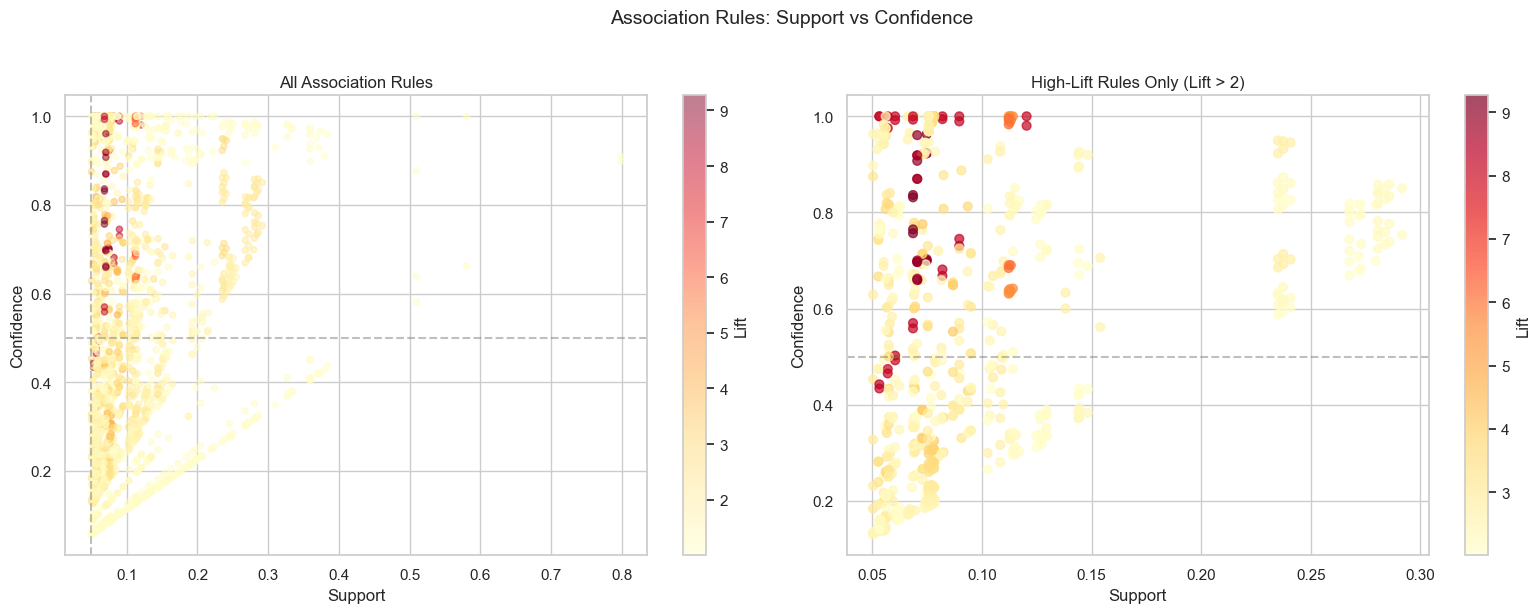

Top-right corner = best rules (high support AND high confidence)
Color intensity = lift (darker = stronger association)


In [37]:
# ── Support vs Confidence scatter (colored by lift) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(rules_apriori['support'], rules_apriori['confidence'],
                          c=rules_apriori['lift'], cmap='YlOrRd', alpha=0.5, s=20)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('All Association Rules')
axes[0].axhline(y=0.5, color='grey', linestyle='--', alpha=0.5)
axes[0].axvline(x=0.05, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=axes[0], label='Lift')

high_lift = rules_apriori[rules_apriori['lift'] > 2]
scatter2 = axes[1].scatter(high_lift['support'], high_lift['confidence'],
                           c=high_lift['lift'], cmap='YlOrRd', alpha=0.7, s=40)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('High-Lift Rules Only (Lift > 2)')
axes[1].axhline(y=0.5, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(scatter2, ax=axes[1], label='Lift')

plt.suptitle('Association Rules: Support vs Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Top-right corner = best rules (high support AND high confidence)')
print('Color intensity = lift (darker = stronger association)')

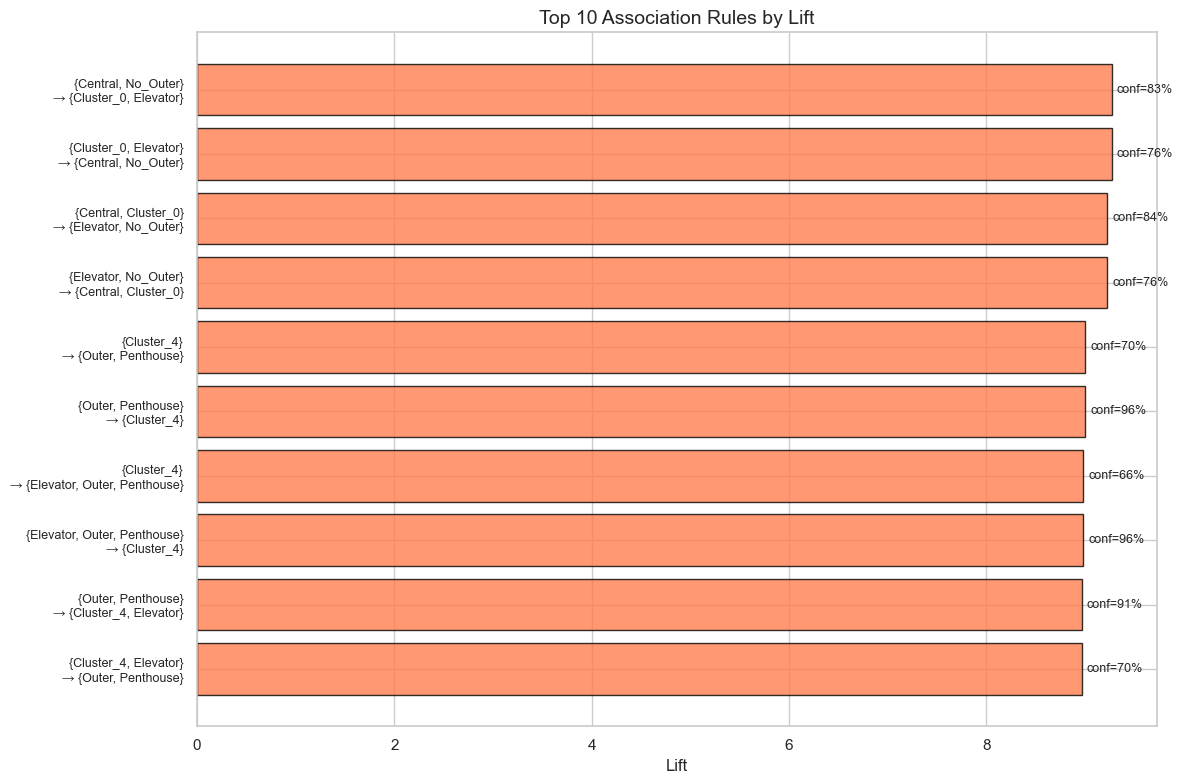

In [38]:
# ── Top 10 rules by lift — horizontal bar chart ──
top10 = rules_apriori.sort_values('lift', ascending=False).head(10)

labels = []
for _, r in top10.iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    con = ', '.join(sorted(r['consequents']))
    labels.append(f'{{{ant}}}\n→ {{{con}}}')

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(labels)), top10['lift'].values, color='coral', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 10 Association Rules by Lift', fontsize=14)
ax.invert_yaxis()

for bar, conf in zip(bars, top10['confidence'].values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'conf={conf:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

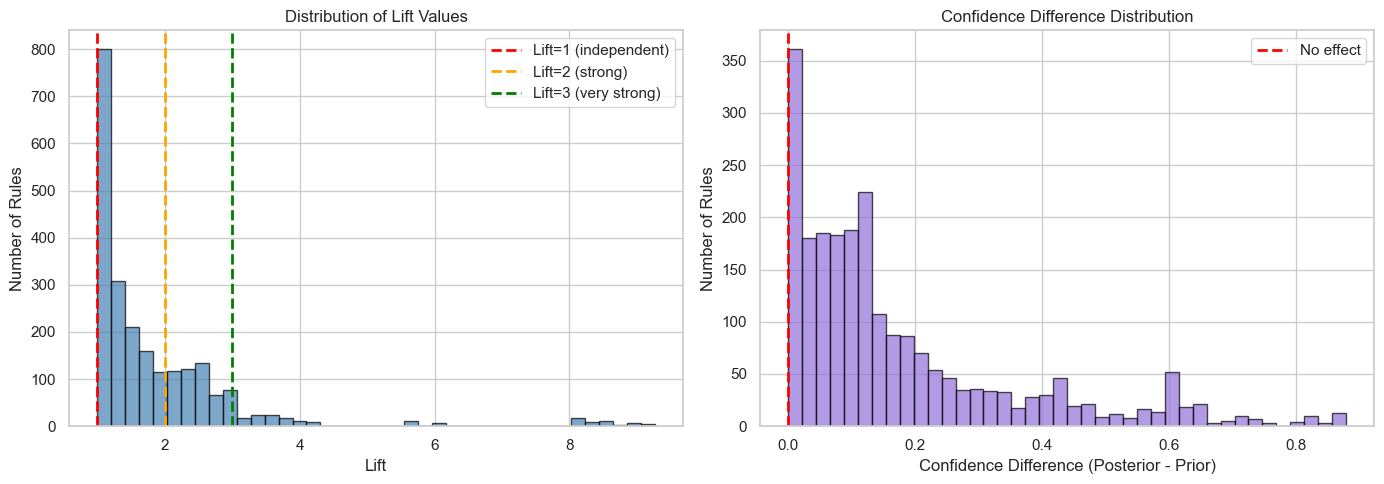

Lift > 1: positive association (items appear together more than expected)
Lift = 1: independent (no association)
Lift < 1: negative association (items appear together LESS than expected)


In [39]:
# ── Lift distribution ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(rules_apriori['lift'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Lift=1 (independent)')
ax1.axvline(x=2, color='orange', linestyle='--', linewidth=2, label='Lift=2 (strong)')
ax1.axvline(x=3, color='green', linestyle='--', linewidth=2, label='Lift=3 (very strong)')
ax1.set_xlabel('Lift')
ax1.set_ylabel('Number of Rules')
ax1.set_title('Distribution of Lift Values')
ax1.legend()

ax2.hist(rules_apriori['confidence_diff'], bins=40, edgecolor='black', alpha=0.7, color='mediumpurple')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
ax2.set_xlabel('Confidence Difference (Posterior - Prior)')
ax2.set_ylabel('Number of Rules')
ax2.set_title('Confidence Difference Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

print('Lift > 1: positive association (items appear together more than expected)')
print('Lift = 1: independent (no association)')
print('Lift < 1: negative association (items appear together LESS than expected)')

## 7. Association Rules Within Segments

One of the most interesting applications: do association patterns DIFFER between segments? If a rule is strong in one segment but absent in another, that reveals segment-specific market dynamics.

In [40]:
# ── Segment-specific rules ──
print('SEGMENT-SPECIFIC ASSOCIATION ANALYSIS')
print('=' * 80)

for cluster in sorted(df['Cluster'].unique()):
    cluster_mask = df['Cluster'] == cluster
    binary_cluster = binary_df[cluster_mask].copy()
    
    # Drop cluster columns for within-segment analysis
    drop_cols = [c for c in binary_cluster.columns if c.startswith('Cluster_')]
    binary_cluster = binary_cluster.drop(columns=drop_cols)
    
    n = len(binary_cluster)
    label = segment_labels[cluster]
    
    print(f'\n{"─"*70}')
    print(f'CLUSTER {cluster}: "{label}" (n={n})')
    print(f'{"─"*70}')
    
    try:
        freq_c = apriori(binary_cluster, min_support=0.08, use_colnames=True, max_len=3)
        if len(freq_c) > 0:
            rules_c = association_rules(freq_c, metric='lift', min_threshold=1.5, num_itemsets=len(freq_c))
            rules_c = rules_c[rules_c['confidence'] > 0.5].sort_values('lift', ascending=False)
            
            print(f'  Rules found: {len(rules_c)} (lift>1.5, conf>50%)')
            for _, r in rules_c.head(5).iterrows():
                ant = ', '.join(sorted(r['antecedents']))
                con = ', '.join(sorted(r['consequents']))
                print(f'    {{{ant}}} → {{{con}}}  lift={r["lift"]:.2f} conf={r["confidence"]:.0%}')
        else:
            print(f'  No frequent itemsets at 8% support')
    except Exception as e:
        print(f'  Could not generate rules: {e}')

SEGMENT-SPECIFIC ASSOCIATION ANALYSIS

──────────────────────────────────────────────────────────────────────
CLUSTER 0: "Entry-Level Interior" (n=251)
──────────────────────────────────────────────────────────────────────
  Rules found: 45 (lift>1.5, conf>50%)
    {High_Rent} → {Elevator, High_PpSqm}  lift=2.11 conf=80%
    {No_Elevator, Small} → {Low_Rent}  lift=2.08 conf=92%
    {High_Rent} → {Central, High_PpSqm}  lift=2.06 conf=83%
    {High_PpSqm, Low_Rent} → {Small}  lift=1.99 conf=100%
    {No_Elevator} → {Low_Rent, Small}  lift=1.96 conf=72%

──────────────────────────────────────────────────────────────────────
CLUSTER 1: "High-Rise Exterior" (n=238)
──────────────────────────────────────────────────────────────────────
  Rules found: 73 (lift>1.5, conf>50%)
    {High_Rent, Many_Beds} → {Large}  lift=2.78 conf=98%
    {Large} → {High_Rent, Many_Beds}  lift=2.78 conf=57%
    {Small} → {High_Floor, Studio_1Bed}  lift=2.73 conf=70%
    {High_Floor, Small} → {Studio_1Bed}  lift=2

## 8. Negative Associations (Lift < 1)

Rules with lift < 1 are equally informative — they reveal feature combinations that are *less likely* than random chance would suggest. These are the market's "contradictions."

In [41]:
# ── Negative associations ──
negative = rules_apriori[
    (rules_apriori['lift'] < 0.5) & 
    (rules_apriori['support'] > 0.05)
].sort_values('lift')

print(f'NEGATIVE ASSOCIATIONS (lift < 0.5, support > 5%)')
print(f'These combinations almost NEVER appear together:')
print(f'{"="*80}')

for _, r in negative.head(10).iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    con = ', '.join(sorted(r['consequents']))
    print(f'  {{{ant}}} → {{{con}}}')
    print(f'    Lift={r["lift"]:.3f} — {(1-r["lift"])*100:.0f}% LESS likely than random')
    print()

NEGATIVE ASSOCIATIONS (lift < 0.5, support > 5%)
These combinations almost NEVER appear together:


## 9. Export Rules

In [42]:
# ── Export top rules ──
export_rules = rules_apriori[rules_apriori['lift'] > 1.5].copy()
export_rules['antecedents'] = export_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
export_rules['consequents'] = export_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
export_rules = export_rules.sort_values('lift', ascending=False)

export_rules.to_excel('Association_Rules.xlsx', index=False)
print(f'Exported {len(export_rules)} rules (lift > 1.5) to Association_Rules.xlsx')

Exported 1076 rules (lift > 1.5) to Association_Rules.xlsx


## 10. Summary & Key Findings

**What we did:**
1. Converted continuous property data into meaningful binary features (21 items: 16 property features + 5 cluster memberships)
2. Ran both **Apriori** and **FP-Growth** — confirmed identical results, measured efficiency difference
3. Analyzed rules at multiple support thresholds to understand sensitivity
4. Filtered for business-relevant rules (lift>2, confidence>50%, support>5%)
5. Examined segment-specific patterns and negative associations

**Key Business Insights:**

The association rules reveal market structure that supports our k=5 segmentation:
- High rent properties cluster with Central location, Large size, and High price/sqm — confirming these as key drivers for the Logit model
- Low rent associates strongly with Small, Studio/1-bed, No_Outer, and southern areas — validating the Interior segment
- The height premium appears in rules: High_Floor + Outer + Elevator → High_Rent
- Negative associations (lift<1) reveal combinations that rarely exist in Madrid's market — like cottages in central zones or penthouses in the south
- Segment-specific rules show that market dynamics differ by cluster — not all associations are universal

**Connection to Phase 3 & 4:** The features that appear in strong association rules (Large, Central, Elevator, High_Floor, High_PpSqm) are natural candidates for the Linear Regression and Logit models.